# Credit Risk Analysis and Prediction — Complete Notebook

This notebook reorganizes the complete workflow from `model(3).py` into focused, executable sections with concise explanations. It includes every stage in the source model, including the additional baseline-threshold comparison, Optuna tuning, SMOTENC, SHAP, RFE, PCA/UMAP/t-SNE, UMAP + GMM clustering, Random Forest cluster classification, and both final risk-segmentation methods.

## Workflow at a glance

| Part | Main focus | Sections |
| --- | --- | --- |
| I | Environment, settings, and reusable functions | Setup |
| II | Data audit, EDA, and engineered indicators | 1–11 |
| III | Preprocessing and Logistic Regression | 12–19 |
| IV | Projection, clustering, and cluster profiles | 20–25 |
| V | Random Forest cluster classifier and interpretation | 26–31 |
| VI | Final probability- and cluster-based risk outputs | 32–33 |

## Before running

- Run the notebook from top to bottom because later cells depend on earlier variables.
- Confirm that `DATA_PATH` points to `default of credit card clients.xls` in your project.
- The original relative output paths are preserved, so the `figures`, `cluster_dataset`, `outputs`, and `terminal_output` directories must exist one level above the notebook working directory.
- The source model keeps the `QtAgg` Matplotlib backend. If the notebook is run in an environment without Qt, use a supported notebook backend instead.
- The optional UMAP + GMM tuning block is commented out by design; the recorded best parameters are used in the following section.


# Part I — Environment and reusable utilities

This part prepares the runtime, shared constants, and helper functions used throughout the notebook.


## Environment setup and imports

**Purpose:** Configures the plotting backend and loads every library used by the workflow, including SHAP, Optuna, UMAP, SMOTENC, and scikit-learn components.

**Key result:** A custom `print` wrapper also keeps console messages for the final terminal-output export.


In [1]:
import os
# import sys
# !{sys.executable} -m pip install --upgrade nbformat

# Disable TensorFlow oneDNN optimization.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# import matplotlib
# matplotlib.use("QtAgg")
import matplotlib.pyplot as plt
# print("MATPLOTLIB BACKEND:", matplotlib.get_backend())

import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import shap
import optuna
import umap
from scipy import stats
from feature_engine.outliers import Winsorizer
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve, silhouette_score,)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer, RobustScaler, StandardScaler
from docx import Document
import builtins

all_outputs = []
original_print = print

def print(*args, **kwargs):
    text = " ".join(map(str, args))
    all_outputs.append(text)
    original_print(*args, **kwargs)


## Global settings

**Purpose:** Defines the visual style, dataset path, target column, random seed, and the recurring repayment, bill, and payment column groups.

**Key result:** These constants keep all later analysis and modeling steps consistent.


In [2]:
sns.set_style("whitegrid")

DATA_PATH = "../dataset/default of credit card clients.xls"
TARGET_COL = "default payment next month"
RANDOM_STATE = 42

PAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLS = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
PAYMENT_COLS = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]


## Helper functions

**Purpose:** Defines reusable distribution plots, boxplot grids, Shapiro-Wilk normality checks, and probability-threshold conversion.

**Key result:** The plotting helpers display each figure and save a high-resolution copy in the figures directory.


In [3]:
def distribution_plot(nrows, ncols, data, columns, save_name):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5))

    if nrows * ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(data=data, x=col, ax=axes[i])
        axes[i].set_title(f"Distribution of {col}")

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"../figures/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def boxplot_grid(nrows, ncols, data, columns, save_name):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5))

    if nrows * ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.boxplot(data=data, x=col, ax=axes[i])
        axes[i].set_title(f"Boxplot of {col}")

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"../figures/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def test_normality(data: pd.DataFrame, columns: list) -> None:
    """Run the Shapiro-Wilk normality test on each column."""
    print("Running normality test:")
    for column in columns:
        values = data[column].dropna()
        if len(values) > 5000:
            values = values.sample(n=5000, random_state=RANDOM_STATE)
        _, p_value = stats.shapiro(values)
        result = "Fail to reject normality." if p_value > 0.05 else "Reject normality."
        print(f"{column}: Shapiro-Wilk test p-value = {p_value:.4f}. {result}")

def apply_threshold(probabilities, threshold=0.5):
    return (probabilities >= threshold).astype(int)


# Part II — Data quality, EDA, and feature engineering

This part cleans the source data, explores portfolio behavior, and constructs interpretable repayment and debt indicators.


## 1. Load data and inspect data quality

**Purpose:** Loads the credit-card dataset, audits its shape, missing values, duplicate rows, duplicate IDs, and data types.

**Key result:** The cleaned dataset removes missing records, duplicate rows, and repeated customer IDs.


In [4]:
df = pd.read_excel(DATA_PATH, header=1)

print("\n=== Raw Dataset Shape ===")
print(df.shape)

print("\n=== Raw Missing Values ===")
print(df.isna().sum())

print("\n=== Raw Duplicate Rows ===")
print(df.duplicated().sum())

id_col = df.columns[0]
print(f"\nID column name: {id_col}")

print("\n=== Raw Duplicate IDs ===")
print(df[id_col].duplicated().sum())

print("\n=== Data Types ===")
print(df.dtypes)

# Check duplicates before cleaning.
dups_full = df.duplicated()
dups_id = df.duplicated(subset=[id_col])

if dups_full.any():
    print("\nExample of fully duplicated rows:")
    print(df.loc[dups_full].head().to_string())

if dups_id.any():
    print("\nExample of duplicate IDs:")
    print(df.loc[dups_id].head().to_string())

# Check duplicates with ID as index.
df_indexed = df.set_index(id_col)
print("\n=== Duplicate Check with ID as Index ===")
print(f"Duplicated rows excluding ID: {df_indexed.duplicated().sum()}")
print(f"Duplicated index values: {df_indexed.index.duplicated().sum()}")

# Remove missing values and duplicates.
df_clean = df.dropna().drop_duplicates().drop_duplicates(subset=[id_col]).copy()

print("\n=== Clean Dataset Shape ===")
print(df_clean.shape)
print(df_clean.info())



=== Raw Dataset Shape ===
(30000, 25)

=== Raw Missing Values ===
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

=== Raw Duplicate Rows ===
0

ID column name: ID

=== Raw Duplicate IDs ===
0

=== Data Types ===
ID                   

## 2. Document and clean categorical encodings

**Purpose:** Documents the encoded meanings of sex, education, marital status, repayment status, and the target.

**Key result:** Rare education codes 5 and 6 are consolidated into the documented `Unknown` category before category counts are reported.


In [5]:
sex_map = {1: "Male", 2: "Female", 3: "Others",}

pay_status_map = {-2: "Undocumented (-2)", -1: "Pay Duly", 0: "Undocumented (0)", 1: "1-Month Delay", 2: "2-Month Delay", 3: "3-Month Delay", 4: "4-Month Delay", 5: "5-Month Delay", 6: "6-Month Delay", 7: "7-Month Delay", 8: "8-Month Delay", 9: "9+ Months Delay",}

education_map = {0: "Unknown", 1: "Graduate School", 2: "University", 3: "High School", 4: "Others",}

marriage_map = {0: "Unknown", 1: "Married", 2: "Single", 3: "Others",}

target_map = {0: "Non-default", 1: "Default",}

print("\n=== SEX Values ===")
sex_counts = df_clean["SEX"].value_counts(dropna=False).sort_index()
sex_df = pd.DataFrame({"SEX": sex_counts.index, "SEX_name": sex_counts.index.map(sex_map), "count": sex_counts.values,})
print(sex_df.to_string(index=False))

print("\n=== EDUCATION Values Before Cleaning ===")
print(df_clean["EDUCATION"].value_counts(dropna=False).sort_index())

# Group EDUCATION values 5 and 6 as Unknown.
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace([5, 6], 0)

print("\n=== EDUCATION Values After Cleaning ===")
education_counts = df_clean["EDUCATION"].value_counts(dropna=False).sort_index()
education_df = pd.DataFrame({"EDUCATION": education_counts.index, "education_name": education_counts.index.map(education_map), "count": education_counts.values,})
print(education_df.to_string(index=False))

print("\n=== MARRIAGE Values ===")
marriage_counts = df_clean["MARRIAGE"].value_counts(dropna=False).sort_index()
marriage_df = pd.DataFrame({"MARRIAGE": marriage_counts.index, "marriage_name": marriage_counts.index.map(marriage_map), "count": marriage_counts.values,})
print(marriage_df.to_string(index=False))

print("\n=== Target Values ===")
target_counts = df_clean[TARGET_COL].value_counts(dropna=False).sort_index()
target_df = pd.DataFrame({"TARGET": target_counts.index, "target_name": target_counts.index.map(target_map), "count": target_counts.values,})
print(target_df.to_string(index=False))

print("\n=== Repayment Status Encodings ===")
for code, label in pay_status_map.items():
    print(f"{code}: {label}")

print("\n=== AGE Range ===")
print(df_clean["AGE"].min(), df_clean["AGE"].max())

print("\n=== LIMIT_BAL Range ===")
print(df_clean["LIMIT_BAL"].min(), df_clean["LIMIT_BAL"].max())



=== SEX Values ===
 SEX SEX_name  count
   1     Male  11888
   2   Female  18112

=== EDUCATION Values Before Cleaning ===
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

=== EDUCATION Values After Cleaning ===
 EDUCATION  education_name  count
         0         Unknown    345
         1 Graduate School  10585
         2      University  14030
         3     High School   4917
         4          Others    123

=== MARRIAGE Values ===
 MARRIAGE marriage_name  count
        0       Unknown     54
        1       Married  13659
        2        Single  15964
        3        Others    323

=== Target Values ===
 TARGET target_name  count
      0 Non-default  23364
      1     Default   6636

=== Repayment Status Encodings ===
-2: Undocumented (-2)
-1: Pay Duly
0: Undocumented (0)
1: 1-Month Delay
2: 2-Month Delay
3: 3-Month Delay
4: 4-Month Delay
5: 5-Month Delay
6: 6-Month Delay
7: 7-Month Delay
8: 8-Month Delay
9: 9+ 

## 3. Prepare an analysis copy for EDA

**Purpose:** Creates a readable analysis copy with categorical labels, age quantile groups, and numeric target values.

**Key result:** It also reports descriptive statistics and normality-test results for numeric variables.


In [6]:
df_clean["age_group"] = pd.qcut(df_clean["AGE"], q=5, duplicates="drop")

df_analysis = df_clean.copy()
df_analysis["EDUCATION"] = df_analysis["EDUCATION"].map(education_map)
df_analysis["SEX"] = df_analysis["SEX"].map(sex_map)
df_analysis["MARRIAGE"] = df_analysis["MARRIAGE"].map(marriage_map)
df_analysis["default_label"] = df_analysis[TARGET_COL].map(target_map)

categorical_columns = ["SEX", "EDUCATION", "MARRIAGE", *PAY_COLS, "default_label",]

print("\n=== Unique Values in Categorical Columns ===")
for col in categorical_columns:
    print(f"{col}: {df_analysis[col].unique()}")

print("\n=== Analysis DataFrame Info ===")
print(df_analysis.info())

numeric_summary_source = df_clean.select_dtypes(include=np.number)
summary_describe = numeric_summary_source.describe().T
summary_describe["Skewness"] = numeric_summary_source.skew()
summary_describe["Kurtosis"] = numeric_summary_source.kurt()

print("\n=== Comprehensive Statistical Overview ===")
print(summary_describe.to_string())



=== Unique Values in Categorical Columns ===
SEX: ['Female' 'Male']
EDUCATION: ['University' 'Graduate School' 'High School' 'Unknown' 'Others']
MARRIAGE: ['Married' 'Single' 'Others' 'Unknown']
PAY_0: [ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_2: [ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_3: [-1  0  2 -2  3  4  6  7  1  5  8]
PAY_4: [-1  0 -2  2  3  4  5  7  6  1  8]
PAY_5: [-2  0 -1  2  3  5  4  7  8  6]
PAY_6: [-2  2  0 -1  3  6  4  7  8  5]
default_label: ['Default' 'Non-default']

=== Analysis DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   ID                          30000 non-null  int64   
 1   LIMIT_BAL                   30000 non-null  int64   
 2   SEX                         30000 non-null  object  
 3   EDUCATION                   30000 non-null  object  
 4   MARRIAGE              

## 4. Basic portfolio visualizations

**Purpose:** Visualizes the distributions and outliers of balance, bill, payment, age, credit-limit, and target variables.

**Key result:** The figures provide a first view of skewness, scale differences, and class imbalance.


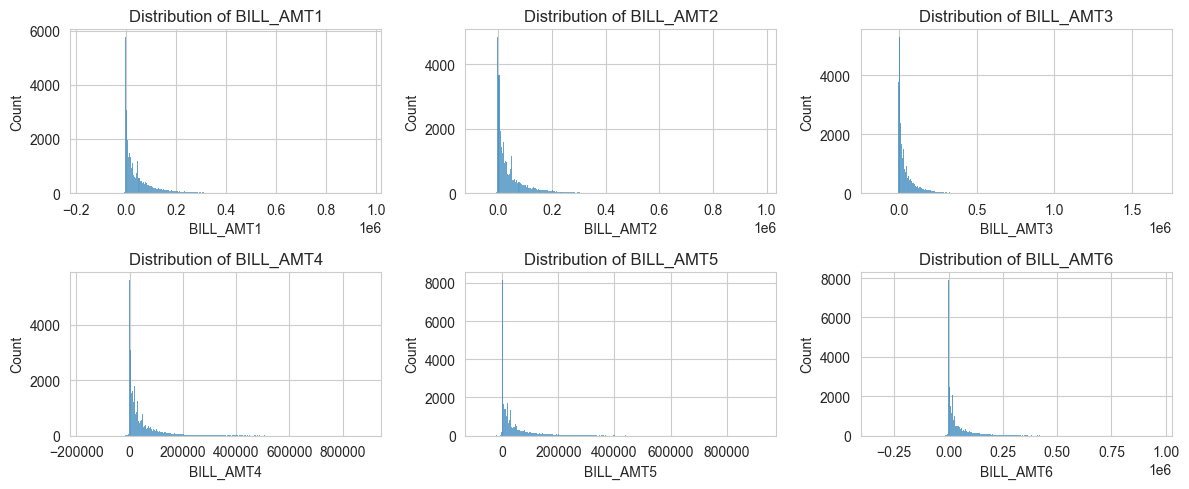

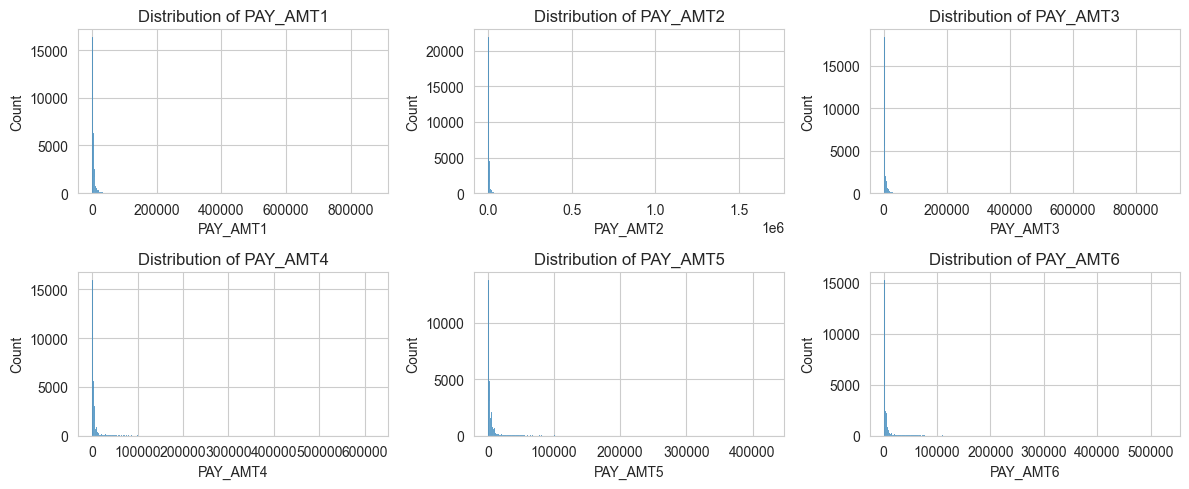

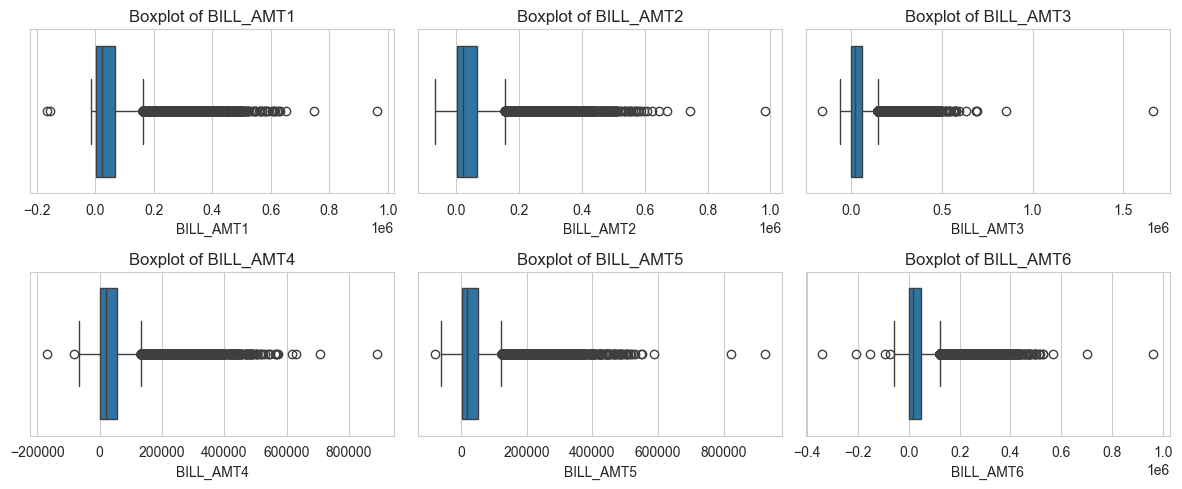

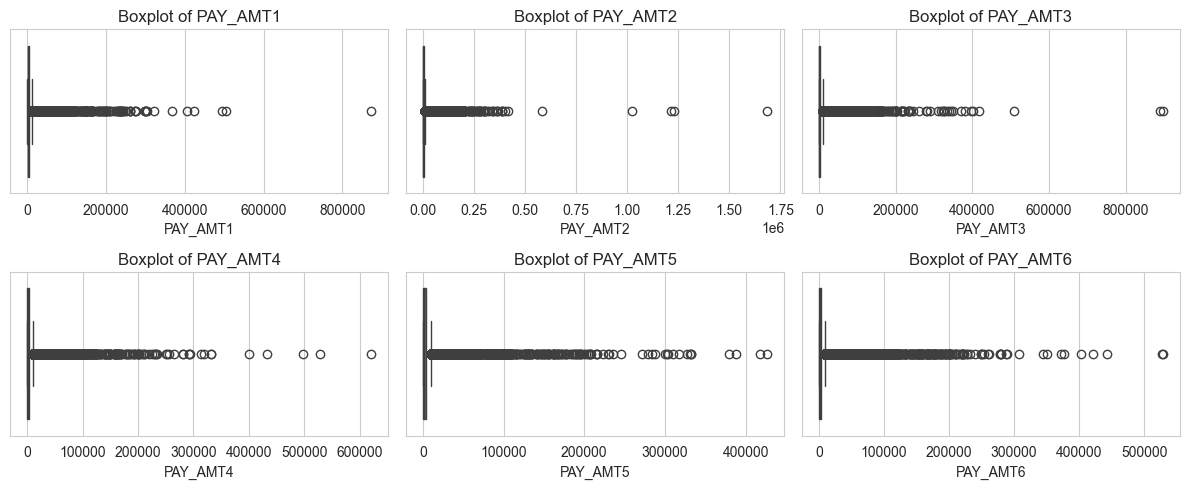


=== Customers by Age Group ===
age_group
(20.999, 27.0]    6604
(27.0, 31.0]      5626
(31.0, 37.0]      6728
(37.0, 43.0]      5056
(43.0, 79.0]      5986
Name: count, dtype: int64


In [7]:
distribution_plot(2, 3, df_analysis, BILL_COLS, "bill_amount_distributions.png")
distribution_plot(2, 3, df_analysis, PAYMENT_COLS, "payment_amount_distributions.png")
boxplot_grid(2, 3, df_analysis, BILL_COLS, "bill_amount_boxplots.png")
boxplot_grid(2, 3, df_analysis, PAYMENT_COLS, "payment_amount_boxplots.png")

plt.figure(figsize=(8, 5))
sns.countplot(data=df_analysis, x="default_label", order=["Non-default", "Default"])
plt.title("Target Class Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../figures/target_class_distribution.png", dpi=300, bbox_inches="tight")
# plt.show()
plt.close()

print("\n=== Customers by Age Group ===")
print(df_analysis["age_group"].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(data=df_analysis, x="age_group")
plt.title("Customers by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=13)
plt.ylabel("Number of Customers", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/customers_by_age_group.png", dpi=300, bbox_inches="tight")
# plt.show()
plt.close()


## 5. Late-payment behavior by customer characteristics

**Purpose:** Derives customer-level late-payment indicators and summarizes them across sex, marital status, age group, and education.

**Key result:** Grouped tables and an interactive chart show which customer segments have higher late-payment rates.



=== Lowest Mean Credit Limits by SEX ===
   SEX  customer_count  mean_limit_bal  median_limit_bal  late_customer_count  late_payment_rate  avg_late_payment_count
  Male           11888   163519.825034          130000.0                 4182           0.351783                0.918153
Female           18112   170086.462014          150000.0                 5887           0.325033                0.779097

=== Highest Mean Credit Limits by SEX ===
   SEX  customer_count  mean_limit_bal  median_limit_bal  late_customer_count  late_payment_rate  avg_late_payment_count
  Male           11888   163519.825034          130000.0                 4182           0.351783                0.918153
Female           18112   170086.462014          150000.0                 5887           0.325033                0.779097

=== Lowest Mean Credit Limits by MARRIAGE ===
MARRIAGE  customer_count  mean_limit_bal  median_limit_bal  late_customer_count  late_payment_rate  avg_late_payment_count
  Others           

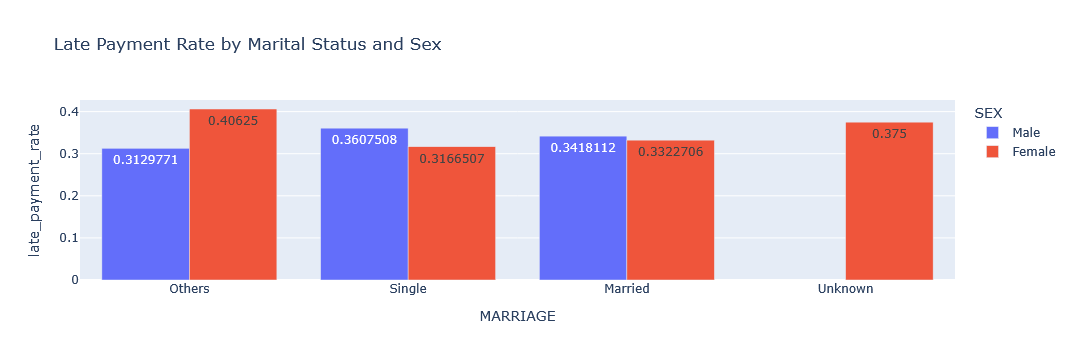

In [8]:
df_analysis["late_payment_count"] = (df_analysis[PAY_COLS] > 0).sum(axis=1)
df_analysis["had_late_payment"] = (df_analysis["late_payment_count"] > 0).astype(int)

customer_group_columns = ["SEX", "MARRIAGE", "age_group", "EDUCATION"]

for col in customer_group_columns:
    group_summary = (df_analysis.groupby(col, as_index=False, observed=True).agg(customer_count=("ID", "count"), mean_limit_bal=("LIMIT_BAL", "mean"), median_limit_bal=("LIMIT_BAL", "median"), late_customer_count=("had_late_payment", "sum"), late_payment_rate=("had_late_payment", "mean"), avg_late_payment_count=("late_payment_count", "mean"),).query("customer_count >= 20").sort_values("mean_limit_bal"))

    print(f"\n=== Lowest Mean Credit Limits by {col} ===")
    print(group_summary.head(5).to_string(index=False))
    print(f"\n=== Highest Mean Credit Limits by {col} ===")
    print(group_summary.tail(5).to_string(index=False))

combined_group_summary = (df_analysis.groupby(customer_group_columns, as_index=False, observed=True).agg(customer_count=("ID", "count"), mean_limit_bal=("LIMIT_BAL", "mean"), median_limit_bal=("LIMIT_BAL", "median"), late_customer_count=("had_late_payment", "sum"), late_payment_rate=("had_late_payment", "mean"), avg_late_payment_count=("late_payment_count", "mean"),).query("customer_count >= 20").sort_values("mean_limit_bal"))

print("\n=== Combined Customer Group Summary: Lowest Mean Credit Limits ===")
print(combined_group_summary.head(10).to_string(index=False))

print("\n=== Combined Customer Group Summary: Highest Mean Credit Limits ===")
print(combined_group_summary.tail(10).to_string(index=False))

sex_marriage_summary = (df_analysis.groupby(["MARRIAGE", "SEX"], as_index=False, observed=True).agg(customer_count=("ID", "count"), mean_limit_bal=("LIMIT_BAL", "mean"), median_limit_bal=("LIMIT_BAL", "median"), late_customer_count=("had_late_payment", "sum"), late_payment_rate=("had_late_payment", "mean"), avg_late_payment_count=("late_payment_count", "mean"),).query("customer_count >= 20").sort_values("mean_limit_bal"))

print("\n=== Marital Status and Sex Summary ===")
print(sex_marriage_summary.to_string(index=False))

fig = px.bar(sex_marriage_summary, x="MARRIAGE", y="late_payment_rate", color="SEX", barmode="group", text_auto=True, title="Late Payment Rate by Marital Status and Sex",)
fig.write_html("../figures/late_payment_rate_by_marital_status_and_sex.html")
fig.show()


## 6. Default vs non-default comparisons

**Purpose:** Compares repayment status, bill amounts, payment amounts, credit limits, and numeric correlations between default and non-default customers.

**Key result:** The resulting summaries and plots reveal variables with visible class separation.


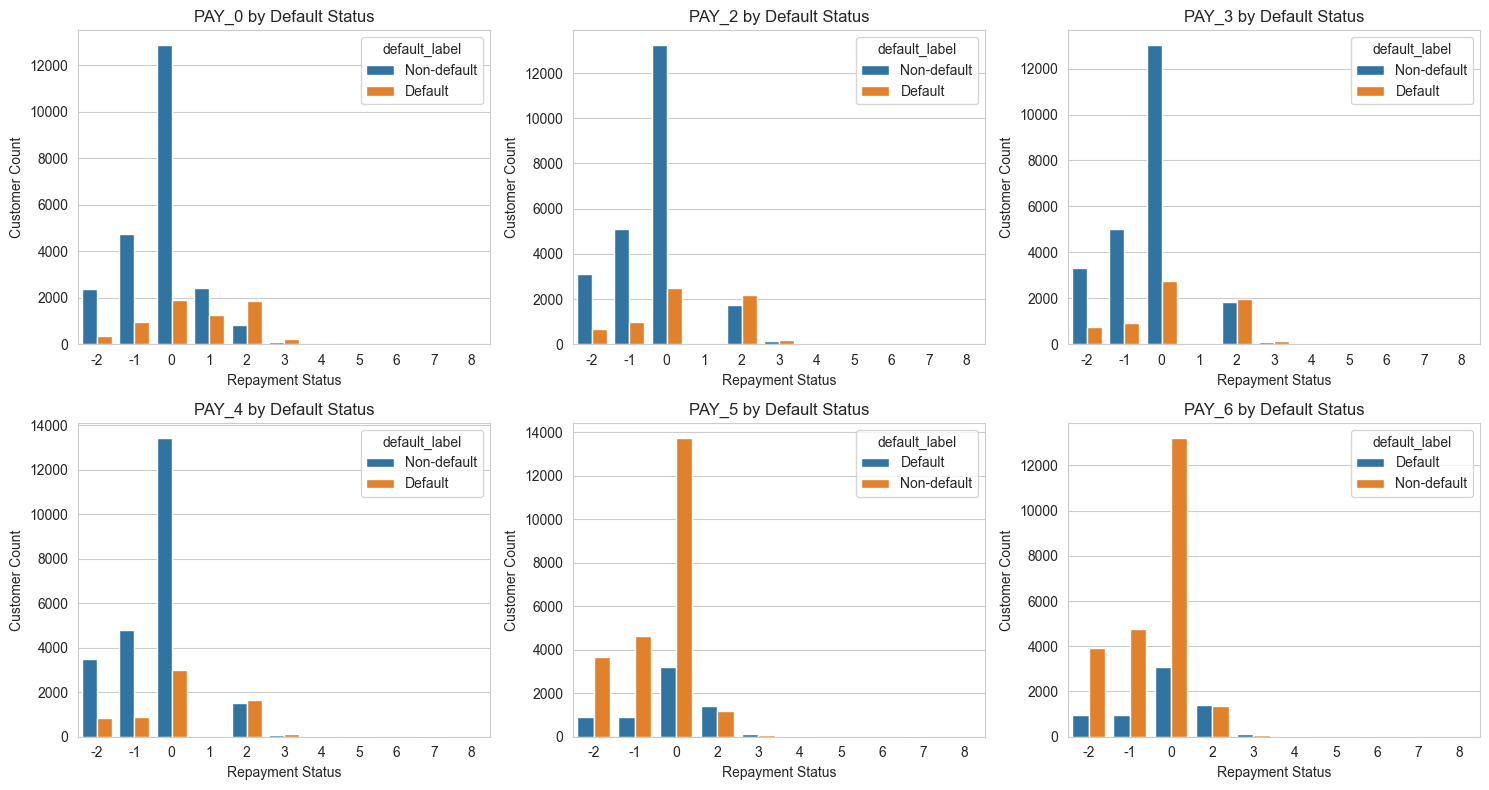


=== PAY_0: Distribution within Default Groups (%) ===
default_label  Default  Non-default
PAY_0                              
-2                5.50        10.25
-1               14.38        20.25
 0               28.45        54.99
 1               18.87        10.43
 2               27.79         3.52
 3                3.68         0.33
 4                0.78         0.10
 5                0.20         0.06
 6                0.09         0.02
 7                0.11         0.01
 8                0.17         0.03

=== PAY_2: Distribution within Default Groups (%) ===
default_label  Default  Non-default
PAY_2                              
-2               10.41        13.23
-1               14.56        21.76
 0               37.72        56.61
 1                0.08         0.10
 2               32.91         7.46
 3                3.03         0.54
 4                0.75         0.21
 5                0.23         0.04
 6                0.14         0.01
 7                0.18    

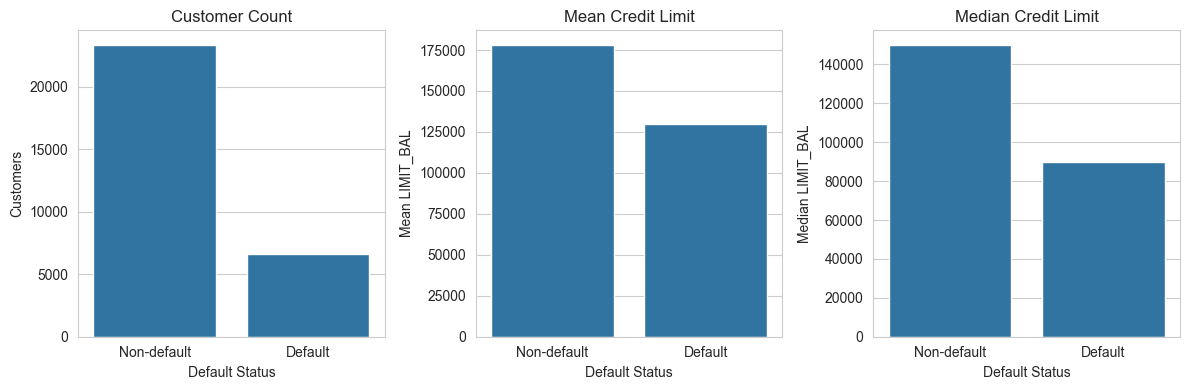

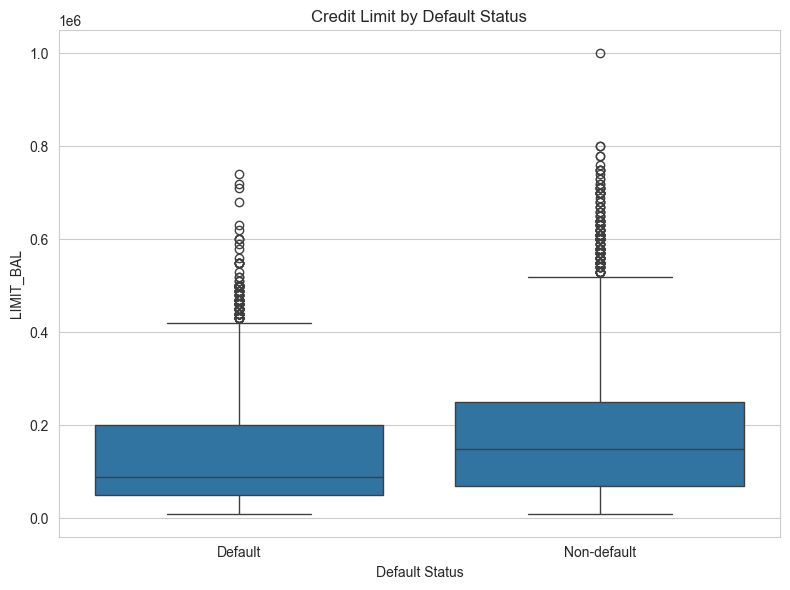

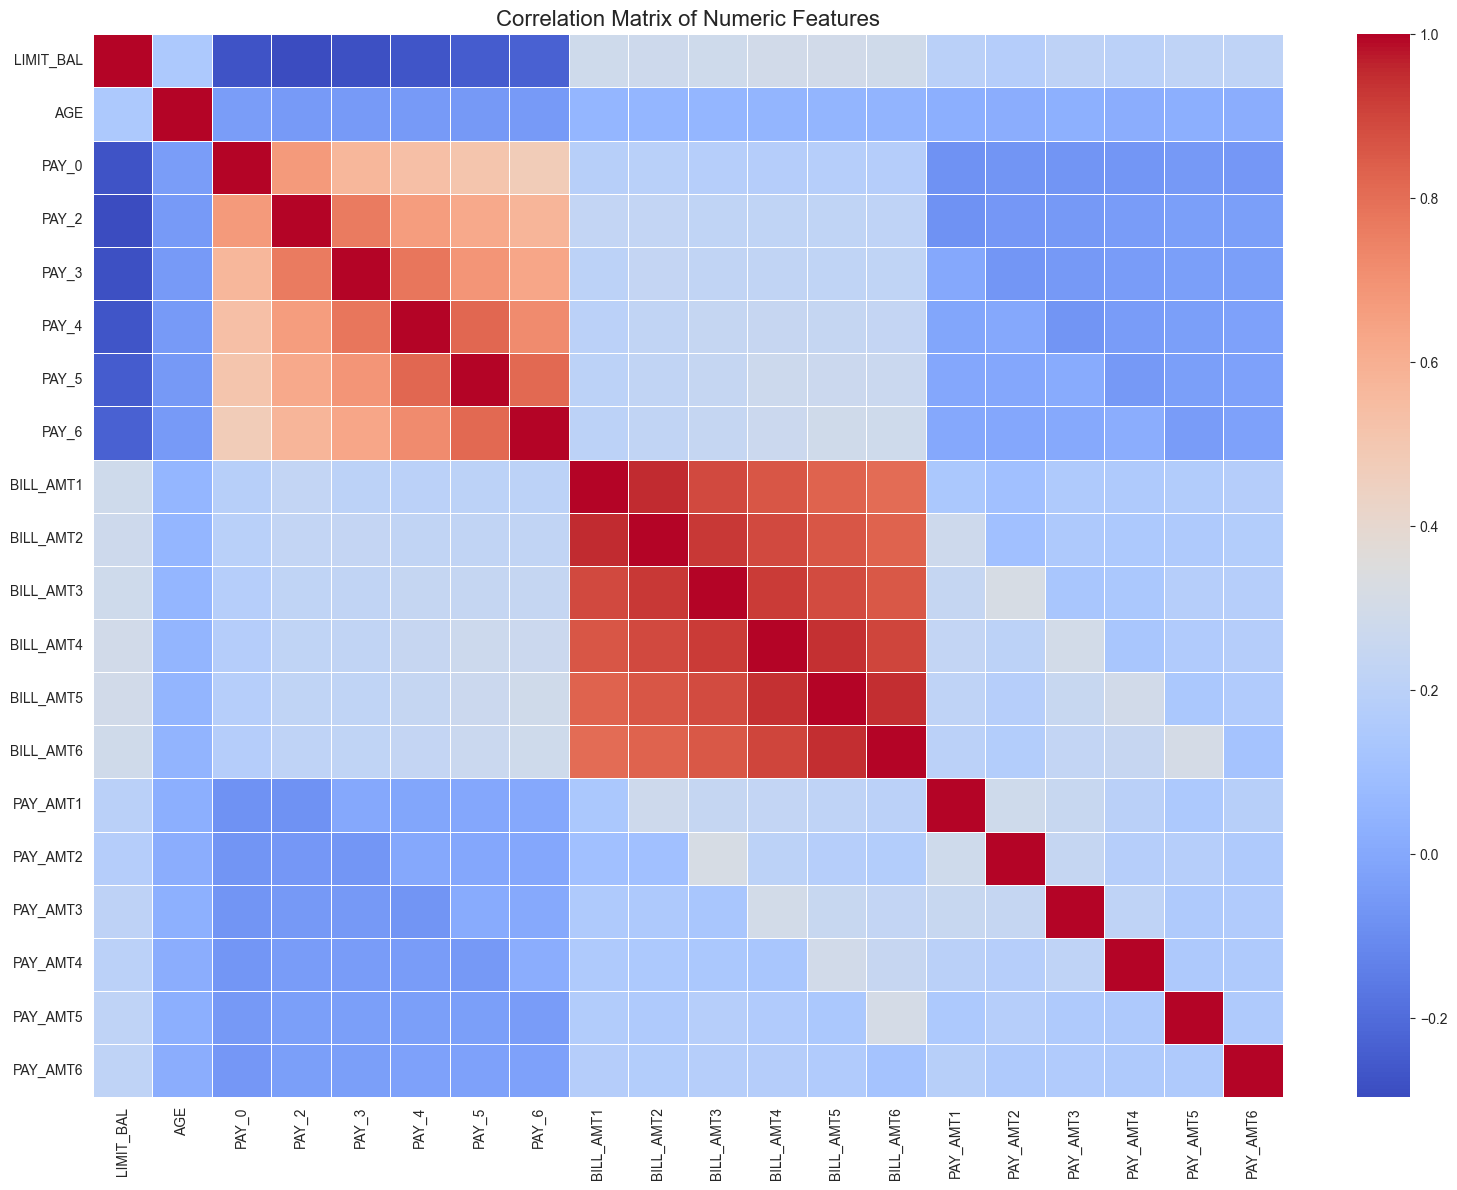

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, PAY_COLS):
    sns.countplot(data=df_analysis, x=col, hue="default_label", ax=ax)
    ax.set_title(f"{col} by Default Status")
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Customer Count")

plt.tight_layout()
plt.savefig("../figures/repayment_status_by_default.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

for col in PAY_COLS:
    print(f"\n=== {col}: Distribution within Default Groups (%) ===")
    pay_table = pd.crosstab(df_analysis[col], df_analysis["default_label"], normalize="columns",) * 100
    print(pay_table.round(2))

late_summary = (df_analysis.groupby("default_label", as_index=False, observed=True).agg(late_payment_rate=("had_late_payment", "mean"), avg_late_payment_count=("late_payment_count", "mean"),))

print("\n=== Late Payment Summary by Default Status ===")
print(late_summary.to_string(index=False))

bill_summary = df_analysis.groupby("default_label", observed=True)[BILL_COLS].agg(["mean", "median"])
print("\n=== Bill Amount Summary by Default Status ===")
print(bill_summary.to_string())

payment_summary = df_analysis.groupby("default_label", observed=True)[PAYMENT_COLS].agg(["mean", "median"])
print("\n=== Payment Amount Summary by Default Status ===")
print(payment_summary.to_string())

limit_summary = (df_analysis.groupby("default_label", observed=True)["LIMIT_BAL"].agg(["count", "mean", "median"]).reset_index().sort_values("mean", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ["count", "mean", "median"]
titles = ["Customer Count", "Mean Credit Limit", "Median Credit Limit"]
y_labels = ["Customers", "Mean LIMIT_BAL", "Median LIMIT_BAL"]

for ax, metric, title, ylabel in zip(axes, metrics, titles, y_labels):
    sns.barplot(data=limit_summary, x="default_label", y=metric, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Default Status")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig("../figures/credit_limit_summary_by_default.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_analysis, x="default_label", y="LIMIT_BAL")
plt.title("Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("LIMIT_BAL")
plt.tight_layout()
plt.savefig("../figures/credit_limit_boxplot_by_default.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

numeric_features = ["LIMIT_BAL", "AGE", *PAY_COLS, *BILL_COLS, *PAYMENT_COLS,]

plt.figure(figsize=(16, 12))
sns.heatmap(df_analysis[numeric_features].corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.tight_layout()
plt.savefig("../figures/correlation_matrix_numeric_features.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 7. Identify repayment variables with the clearest separation

**Purpose:** Ranks repayment-status, payment-amount, and bill-amount variables by their difference between the two target classes.

**Key result:** Comparison charts and the monthly payment trend highlight the strongest repayment signals.



=== PAY Separation ===
feature  Non-default   Default  difference
  PAY_0    14.505222 51.672694   37.167473
  PAY_2     8.397535 37.311634   28.914099
  PAY_3     8.607259 33.182640   24.575381
  PAY_4     6.980825 28.315250   21.334425
  PAY_5     5.645437 24.849307   19.203869
  PAY_6     6.283171 24.276673   17.993502

=== Payment Amount Separation ===
target_numeric  Non-default  Default  difference
PAY_AMT1             2459.5   1636.0       823.5
PAY_AMT3             2000.0   1222.0       778.0
PAY_AMT5             1765.0   1000.0       765.0
PAY_AMT4             1734.0   1000.0       734.0
PAY_AMT2             2247.5   1533.5       714.0
PAY_AMT6             1706.0   1000.0       706.0

=== Bill Amount Separation ===
target_numeric  Non-default  Default  difference
BILL_AMT1           23119.5  20185.0      2934.5
BILL_AMT2           21660.5  20300.5      1360.0
BILL_AMT6           16679.0  18028.5      1349.5
BILL_AMT5           17998.0  18478.5       480.5
BILL_AMT3           

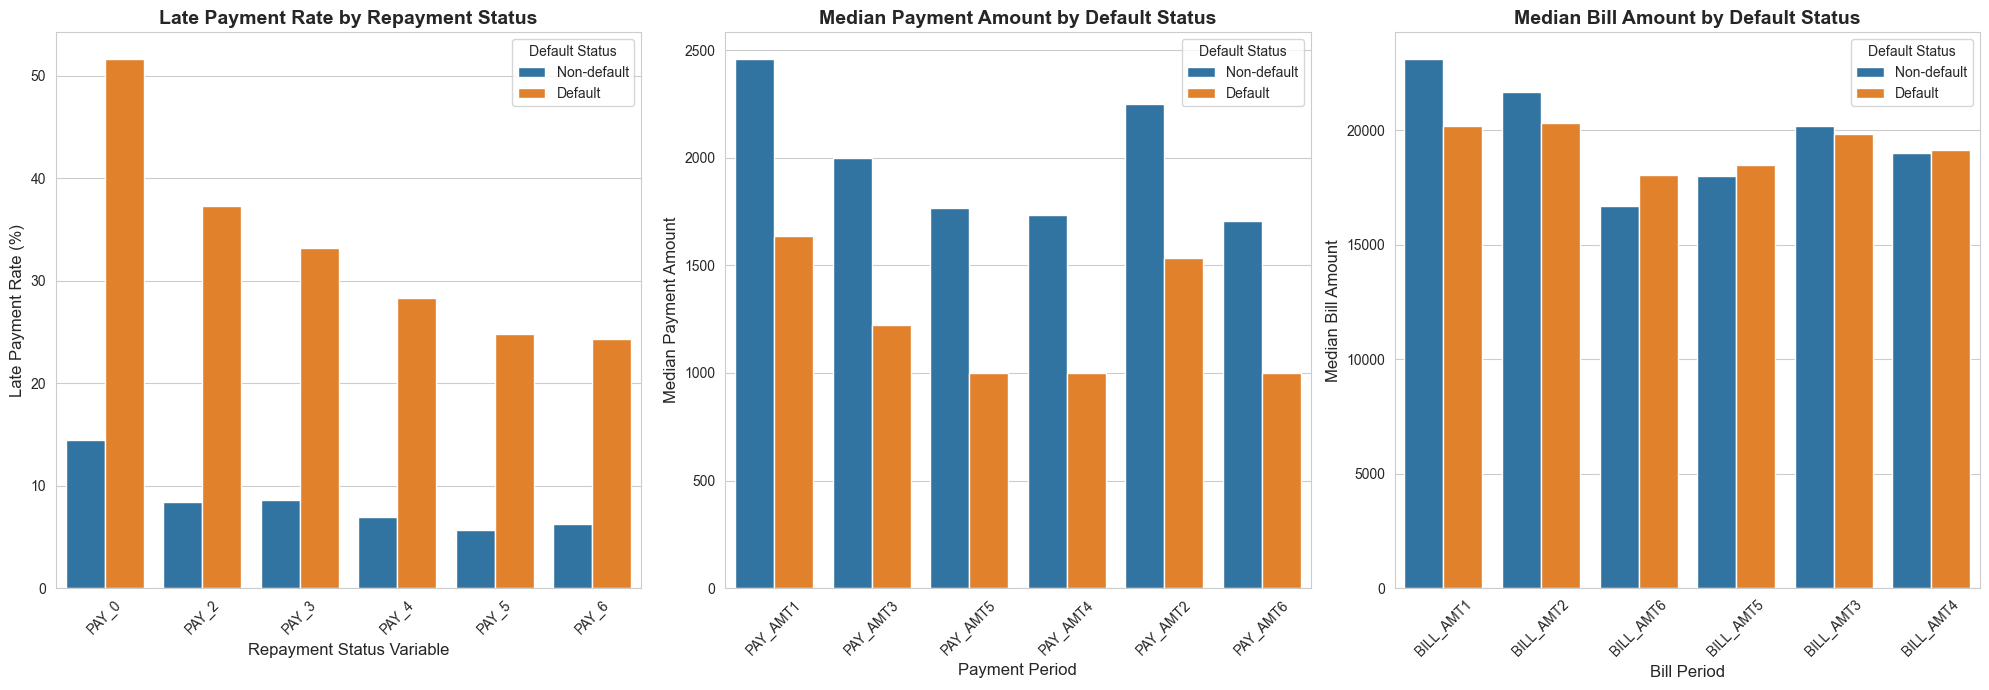

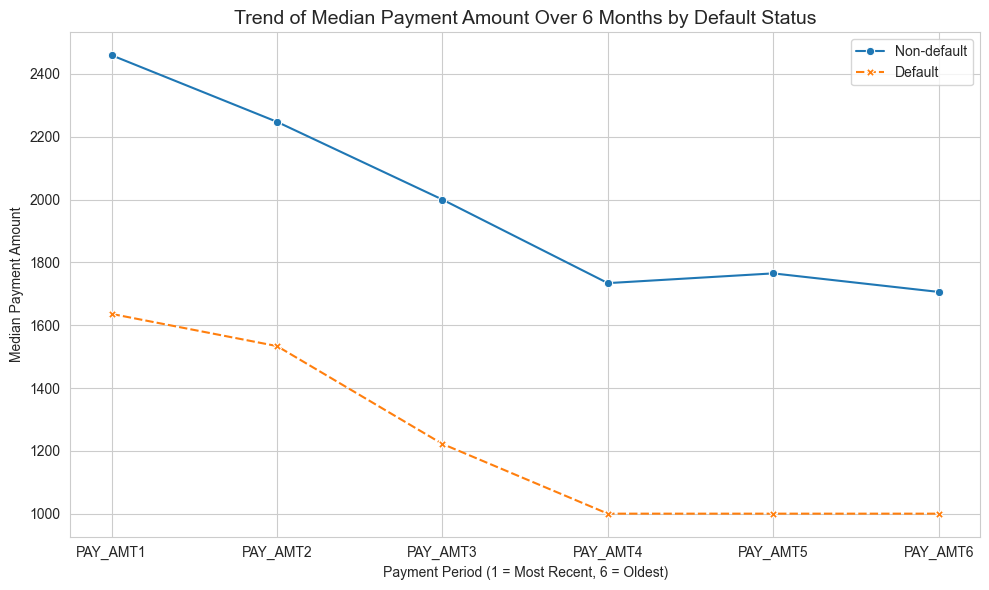

In [10]:
df_analysis["target_numeric"] = df_analysis[TARGET_COL].astype(int)

pay_separation = []

for col in PAY_COLS:
    rates = df_analysis.groupby("target_numeric")[col].apply(lambda x: (x > 0).mean() * 100)

    non_default_rate = rates.get(0, np.nan)
    default_rate = rates.get(1, np.nan)

    pay_separation.append({"feature": col, "Non-default": non_default_rate, "Default": default_rate, "difference": abs(default_rate - non_default_rate),})

pay_separation = pd.DataFrame(pay_separation).sort_values("difference", ascending=False)

print("\n=== PAY Separation ===")
print(pay_separation.to_string(index=False))

payment_separation = (df_analysis.groupby("target_numeric")[PAYMENT_COLS].median().T.rename(columns={0: "Non-default", 1: "Default"}))
payment_separation["difference"] = abs(payment_separation["Default"] - payment_separation["Non-default"])
payment_separation = payment_separation.sort_values("difference", ascending=False)

print("\n=== Payment Amount Separation ===")
print(payment_separation.to_string())

bill_separation = (df_analysis.groupby("target_numeric")[BILL_COLS].median().T.rename(columns={0: "Non-default", 1: "Default"}))
bill_separation["difference"] = abs(bill_separation["Default"] - bill_separation["Non-default"])
bill_separation = bill_separation.sort_values("difference", ascending=False)

print("\n=== Bill Amount Separation ===")
print(bill_separation.to_string())

plot_configs = [{"data": pay_separation.melt(id_vars=["feature", "difference"], value_vars=["Non-default", "Default"], var_name="Default Status", value_name="Late Payment Rate",), "x": "feature", "y": "Late Payment Rate", "title": "Late Payment Rate by Repayment Status", "xlabel": "Repayment Status Variable", "ylabel": "Late Payment Rate (%)",}, {"data": payment_separation.reset_index().rename(columns={"index": "feature"}).melt(id_vars=["feature", "difference"], value_vars=["Non-default", "Default"], var_name="Default Status", value_name="Median Payment",), "x": "feature", "y": "Median Payment", "title": "Median Payment Amount by Default Status", "xlabel": "Payment Period", "ylabel": "Median Payment Amount",}, {"data": bill_separation.reset_index().rename(columns={"index": "feature"}).melt(id_vars=["feature", "difference"], value_vars=["Non-default", "Default"], var_name="Default Status", value_name="Median Bill",), "x": "feature", "y": "Median Bill", "title": "Median Bill Amount by Default Status", "xlabel": "Bill Period", "ylabel": "Median Bill Amount",},]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, config in zip(axes, plot_configs):
    sns.barplot(data=config["data"], x=config["x"], y=config["y"], hue="Default Status", ax=ax,)
    ax.set_title(config["title"], fontsize=14, fontweight="bold")
    ax.set_xlabel(config["xlabel"], fontsize=12)
    ax.set_ylabel(config["ylabel"], fontsize=12)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../figures/repayment_bill_payment_separation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

payment_trend = df_analysis.groupby("target_numeric")[PAYMENT_COLS].median().T
payment_trend.columns = ["Non-default", "Default"]

plt.figure(figsize=(10, 6))
sns.lineplot(data=payment_trend, markers=True)
plt.title("Trend of Median Payment Amount Over 6 Months by Default Status", fontsize=14)
plt.xlabel("Payment Period (1 = Most Recent, 6 = Oldest)")
plt.ylabel("Median Payment Amount")
plt.xticks(ticks=range(6), labels=["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"],)
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/median_payment_trend_by_default.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 8. Engineered repayment and debt indicators

**Purpose:** Creates a weighted repayment ratio, total bill and payment amounts, debt balance, and debt ratio.

**Key result:** Segment-level summaries connect these engineered indicators with late-payment and default behavior.


In [11]:
# Calculate repayment weights.
diff_dict = dict(zip(pay_separation["feature"], pay_separation["difference"]))
diffs = [diff_dict[col] for col in PAY_COLS]
total_diff = sum(diffs)

if total_diff == 0:
    weights = [1 / len(PAY_COLS)] * len(PAY_COLS)
else:
    weights = [difference / total_diff for difference in diffs]

# Give more weight to the most recent month.
emphasis_factor = 1.4
weights[0] *= emphasis_factor
weights = [weight / sum(weights) for weight in weights]

print("\n=== Automatically Calculated Repayment Weights ===")
for col, weight in zip(PAY_COLS, weights):
    print(f"{col}: {weight:.4f}")

weighted_ratio = pd.Series(0.0, index=df_analysis.index)

for i in range(6):
    ratio = df_analysis[PAYMENT_COLS[i]] / df_analysis[BILL_COLS[i]].replace(0, 1)
    ratio = ratio.clip(lower=0, upper=1)
    weighted_ratio += weights[i] * ratio

df_analysis["repayment_ratio"] = weighted_ratio

df_analysis["total_bill"] = df_analysis[BILL_COLS].sum(axis=1)
df_analysis["total_pay"] = df_analysis[PAYMENT_COLS].sum(axis=1)
df_analysis["debt_balance"] = df_analysis["total_bill"] - df_analysis["total_pay"]
df_analysis["debt_ratio"] = df_analysis["debt_balance"] / df_analysis["LIMIT_BAL"]

print("\n=== Weighted Repayment Ratio Distribution ===")
print(df_analysis["repayment_ratio"].describe())

group_repayment = (df_analysis.groupby(customer_group_columns, as_index=False, observed=True).agg(customer_count=("ID", "count"), mean_repayment_ratio=("repayment_ratio", "mean"), median_repayment_ratio=("repayment_ratio", "median"), default_rate=("target_numeric", "mean"), late_payment_rate=("had_late_payment", "mean"), median_total_bill=("total_bill", "median"), median_total_pay=("total_pay", "median"), mean_debt_balance=("debt_balance", "mean"), median_debt_balance=("debt_balance", "median"), mean_debt_ratio=("debt_ratio", "mean"), median_debt_ratio=("debt_ratio", "median"),).sort_values("median_repayment_ratio", ascending=False))

for col in customer_group_columns:
    group_detail_repayment = (df_analysis.groupby(col, as_index=False, observed=True).agg(customer_count=("ID", "count"), mean_repayment_ratio=("repayment_ratio", "mean"), median_repayment_ratio=("repayment_ratio", "median"), default_rate=("target_numeric", "mean"), late_payment_rate=("had_late_payment", "mean"), median_total_bill=("total_bill", "median"), median_total_pay=("total_pay", "median"), mean_debt_balance=("debt_balance", "mean"), median_debt_balance=("debt_balance", "median"), mean_debt_ratio=("debt_ratio", "mean"), median_debt_ratio=("debt_ratio", "median"),).query("customer_count >= 50").sort_values("median_repayment_ratio", ascending=False))

    print(f"\n=== Repayment Summary by {col} (Customer Count >= 50) ===")
    print(group_detail_repayment.to_string(index=False))

print("\n=== Combined Repayment Summary ===")
print(group_repayment.to_string(index=False))

print("\n=== Combined Repayment Summary (Customer Count >= 50) ===")
group_repayment_filtered = group_repayment.query("customer_count >= 50")
print(group_repayment_filtered.to_string(index=False))



=== Automatically Calculated Repayment Weights ===
PAY_0: 0.3172
PAY_2: 0.1762
PAY_3: 0.1498
PAY_4: 0.1300
PAY_5: 0.1171
PAY_6: 0.1097

=== Weighted Repayment Ratio Distribution ===
count    30000.000000
mean         0.233383
std          0.262401
min          0.000000
25%          0.041883
50%          0.095677
75%          0.372176
max          1.000000
Name: repayment_ratio, dtype: float64

=== Repayment Summary by SEX (Customer Count >= 50) ===
   SEX  customer_count  mean_repayment_ratio  median_repayment_ratio  default_rate  late_payment_rate  median_total_bill  median_total_pay  mean_debt_balance  median_debt_balance  mean_debt_ratio  median_debt_ratio
Female           18112              0.242772                0.104351      0.207763           0.325033           121573.0           14789.0      230480.557420              96396.0         1.897066           1.089908
  Male           11888              0.219077                0.085631      0.241672           0.351783           1322

## 9. Sensitivity analysis for the engineered repayment ratio

**Purpose:** Tests multiple repayment-ratio cutoffs to measure how customer coverage and observed default rate change.

**Key result:** The threshold table and chart support a transparent operational cutoff choice.



=== Repayment Ratio Sensitivity Analysis ===
 threshold  high_risk_count  high_risk_default_rate  pct_of_defaults_captured  pct_of_customers_flagged
       0.3            21031                0.252722                 80.093430                 70.103333
       0.5            24366                0.240376                 88.261001                 81.220000
       0.7            27224                0.229944                 94.333936                 90.746667
       0.9            29477                0.221936                 98.583484                 98.256667


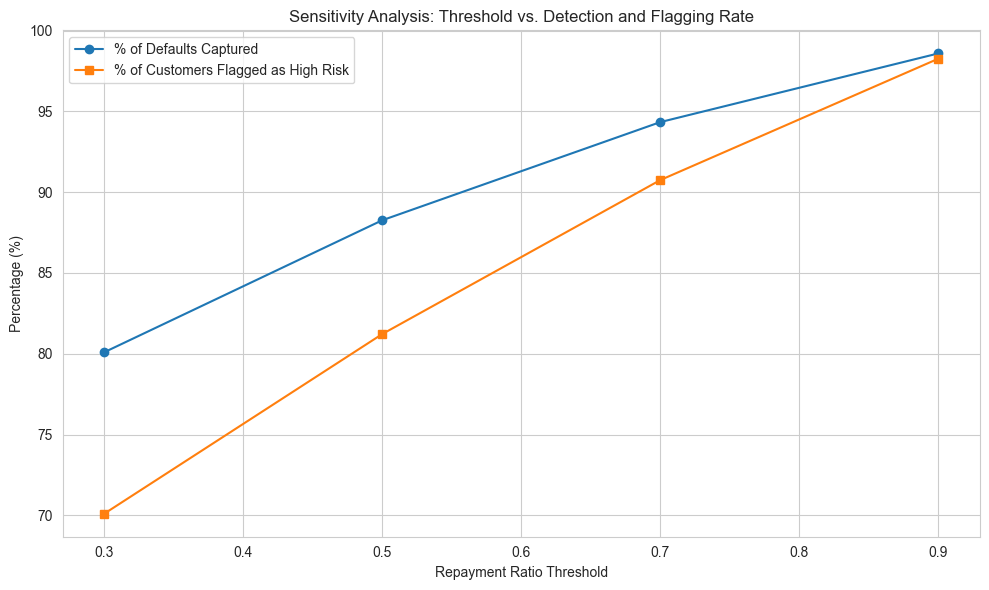

In [12]:
repayment_thresholds = [0.3, 0.5, 0.7, 0.9]
repayment_threshold_results = []

for threshold in repayment_thresholds:
    temp_df = df_analysis.copy()
    temp_df["risk_group_test"] = np.where(temp_df["repayment_ratio"] < threshold, "High Risk", "Low Risk",)

    high_risk_mask = temp_df["risk_group_test"] == "High Risk"
    high_risk_default_rate = temp_df.loc[high_risk_mask, "target_numeric"].mean()
    high_risk_count = high_risk_mask.sum()
    total_defaults = temp_df["target_numeric"].sum()
    high_risk_defaults = temp_df.loc[high_risk_mask, "target_numeric"].sum()

    repayment_threshold_results.append({"threshold": threshold, "high_risk_count": high_risk_count, "high_risk_default_rate": high_risk_default_rate, "pct_of_defaults_captured": (high_risk_defaults / total_defaults) * 100, "pct_of_customers_flagged": (high_risk_count / len(temp_df)) * 100,})

repayment_threshold_results_df = pd.DataFrame(repayment_threshold_results)

print("\n=== Repayment Ratio Sensitivity Analysis ===")
print(repayment_threshold_results_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.plot(repayment_threshold_results_df["threshold"], repayment_threshold_results_df["pct_of_defaults_captured"], marker="o", label="% of Defaults Captured",)
plt.plot(repayment_threshold_results_df["threshold"], repayment_threshold_results_df["pct_of_customers_flagged"], marker="s", label="% of Customers Flagged as High Risk",)
plt.xlabel("Repayment Ratio Threshold")
plt.ylabel("Percentage (%)")
plt.title("Sensitivity Analysis: Threshold vs. Detection and Flagging Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/repayment_ratio_threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 10. Interaction analysis: PAY_0 and marital status

**Purpose:** Examines the joint relationship between the most recent repayment status (`PAY_0`), marital status, and default outcome.

**Key result:** The normalized interaction table and visualization expose combinations associated with higher risk.



=== Interaction: PAY_0 and MARRIAGE vs Default ===
default_label   Default  Non-default
MARRIAGE PAY_0                      
Married  -2        2.86         5.10
         -1        7.25         9.75
          0       13.17        23.29
          1        8.89         4.83
          2       13.85         1.55
          3        1.66         0.13
          4        0.36         0.05
          5        0.08         0.01
          6        0.03         0.01
          7        0.06         0.01
          8        0.11         0.01
Others   -2        0.03         0.05
         -1        0.15         0.14
          0        0.48         0.65
          1        0.27         0.12
          2        0.27         0.05
          3        0.06         0.01
Single   -2        2.59         5.07
         -1        6.98        10.30
          0       14.77        30.98
          1        9.69         5.45
          2       13.65         1.91
          3        1.96         0.19
          4        0.42

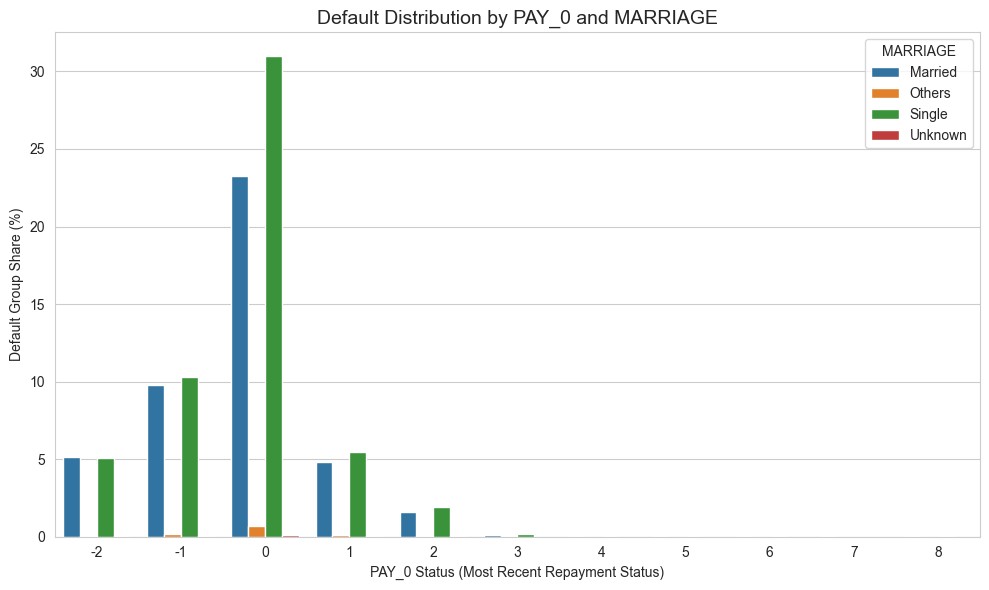

In [13]:
interaction_table = pd.crosstab([df_analysis["MARRIAGE"], df_analysis["PAY_0"]], df_analysis["default_label"], normalize="columns",) * 100

print("\n=== Interaction: PAY_0 and MARRIAGE vs Default ===")
print(interaction_table.round(2))

interaction_plot = interaction_table.reset_index()
interaction_plot.columns = ["MARRIAGE", "PAY_0", "Non-default", "Default"]

plt.figure(figsize=(10, 6))
sns.barplot(data=interaction_plot, x="PAY_0", y="Default", hue="MARRIAGE")
plt.title("Default Distribution by PAY_0 and MARRIAGE", fontsize=14)
plt.xlabel("PAY_0 Status (Most Recent Repayment Status)")
plt.ylabel("Default Group Share (%)")
plt.legend(title="MARRIAGE")
plt.tight_layout()
plt.savefig("../figures/pay0_marriage_default_interaction.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 11. PCA on payment amounts

**Purpose:** Standardizes the six payment-amount variables and compresses them into two principal components.

**Key result:** Explained variance, component loadings, and a target-colored scatter plot summarize their shared structure.



=== PCA Loadings for Payment Amounts ===
            PC1    PC2
PAY_AMT1  0.454 -0.334
PAY_AMT2  0.446 -0.278
PAY_AMT3  0.440 -0.293
PAY_AMT4  0.392 -0.038
PAY_AMT5  0.348  0.672
PAY_AMT6  0.357  0.522


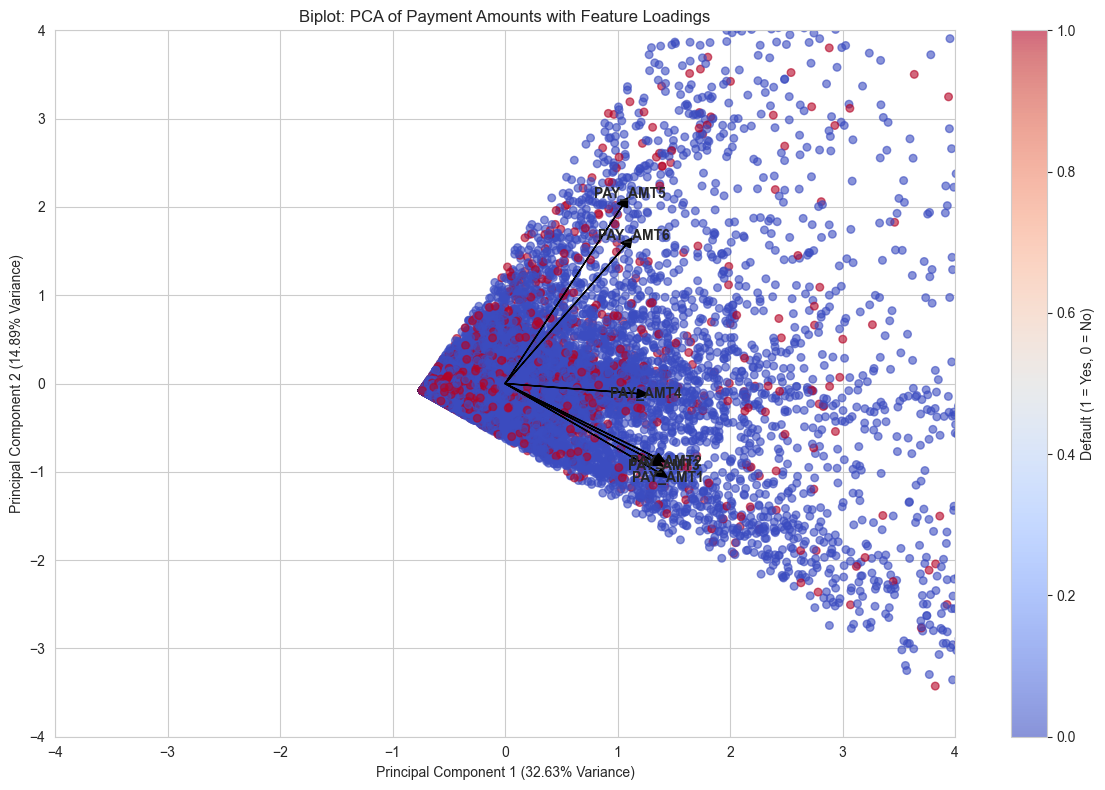

In [14]:
payment_scaler = StandardScaler()
X_payment_scaled = payment_scaler.fit_transform(df_analysis[PAYMENT_COLS])

payment_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_payment_pca = payment_pca.fit_transform(X_payment_scaled)

df_analysis["PC1"] = X_payment_pca[:, 0]
df_analysis["PC2"] = X_payment_pca[:, 1]

payment_loadings = pd.DataFrame(payment_pca.components_.T, columns=["PC1", "PC2"], index=PAYMENT_COLS,)

print("\n=== PCA Loadings for Payment Amounts ===")
print(payment_loadings.round(3))

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_payment_pca[:, 0], X_payment_pca[:, 1], c=df_analysis["target_numeric"], cmap="coolwarm", alpha=0.6, s=30,)
plt.colorbar(scatter, label="Default (1 = Yes, 0 = No)")

for i, (x_value, y_value) in enumerate(payment_pca.components_.T):
    plt.arrow(0, 0, x_value * 3, y_value * 3, head_width=0.1, head_length=0.1, fc="black", ec="black",)
    plt.text(x_value * 3.2, y_value * 3.2, PAYMENT_COLS[i], fontsize=10, ha="center", va="center", fontweight="bold",)

plt.xlabel(f"Principal Component 1 ({payment_pca.explained_variance_ratio_[0] * 100:.2f}% Variance)")
plt.ylabel(f"Principal Component 2 ({payment_pca.explained_variance_ratio_[1] * 100:.2f}% Variance)")
plt.title("Biplot: PCA of Payment Amounts with Feature Loadings")
plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.tight_layout()
plt.savefig("../figures/pca_payment_amounts_biplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# Part III — Preprocessing and Logistic Regression

This part prepares leakage-safe feature matrices, builds baseline and optimized Logistic Regression models, and interprets their predictions.


## 12. Prepare data for modeling and clustering

**Purpose:** Builds the modeling table from the original project features, separates feature types, and creates a stratified train/test split.

**Key result:** The split is reused by the supervised and clustering workflows to keep evaluation consistent.


In [15]:
# Use original project features for modeling.
model_data = df_analysis.drop(columns=[id_col, "age_group", "default_label", "target_numeric", "late_payment_count", "had_late_payment", "repayment_ratio", "total_bill", "total_pay", "debt_balance", "debt_ratio", "PC1", "PC2",], errors="ignore",).copy()

nominal_cols = ["SEX", "EDUCATION", "MARRIAGE"]

continuous_cols = ["LIMIT_BAL", "AGE", *BILL_COLS, *PAYMENT_COLS]
ordinal_cols = PAY_COLS
numeric_cols = [*continuous_cols, *ordinal_cols]
smote_categorical_cols = [*ordinal_cols, *nominal_cols]

model_data[continuous_cols] = model_data[continuous_cols].astype(float)

X = model_data.drop(columns=[TARGET_COL])
y = model_data[TARGET_COL].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,)

print("\n=== Train/Test Split ===")
print(f"Train size: {len(X_train_raw)}")
print(f"Test size: {len(X_test_raw)}")



=== Train/Test Split ===
Train size: 24000
Test size: 6000


## 13. Preprocessing

**Purpose:** Applies winsorization, Yeo-Johnson transformation, and robust scaling to continuous variables, passes ordinal repayment codes through, and one-hot encodes nominal variables.

**Key result:** The fitted transformer produces named train, test, and full-dataset feature matrices.


In [17]:
preprocessor = ColumnTransformer(transformers=[("num", Pipeline(steps=[("winsorizer", Winsorizer(capping_method="quantiles", tail="both", fold=0.05),)
    , ("power", PowerTransformer(method="yeo-johnson")), ("scaler", RobustScaler()),]), continuous_cols,),
    ("ord", "passthrough", ordinal_cols,),
    ("cat", Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False),)]), nominal_cols,),])

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train, columns=feature_names, index=X_train_raw.index)
X_test_df = pd.DataFrame(X_test, columns=feature_names, index=X_test_raw.index)


## 13.1. Distribution and outlier checks before preprocessing

**Purpose:** Profiles the original training variables with distribution plots, boxplots, and normality tests.

**Key result:** These results provide the baseline used to assess the effect of preprocessing.


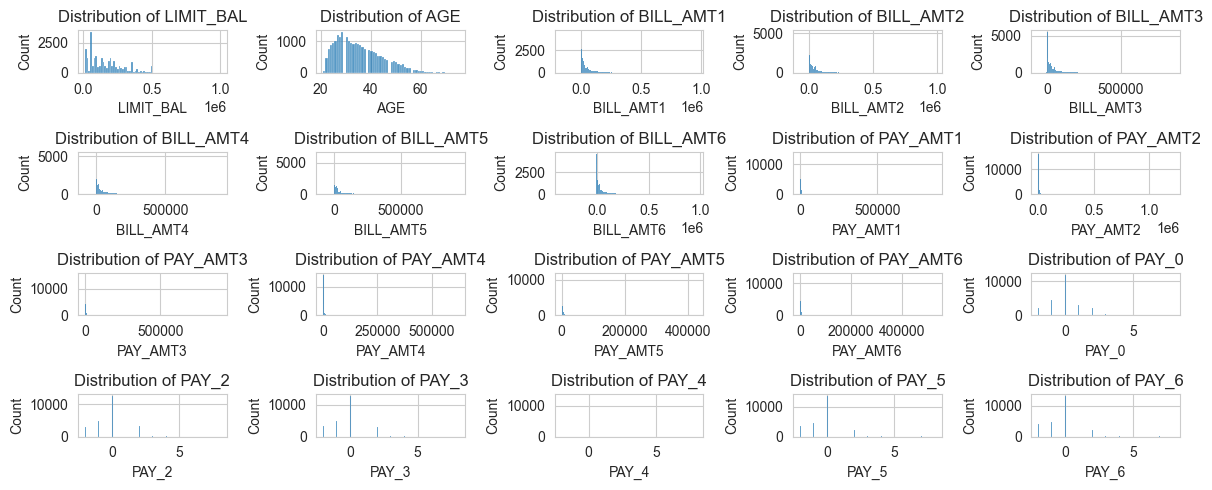

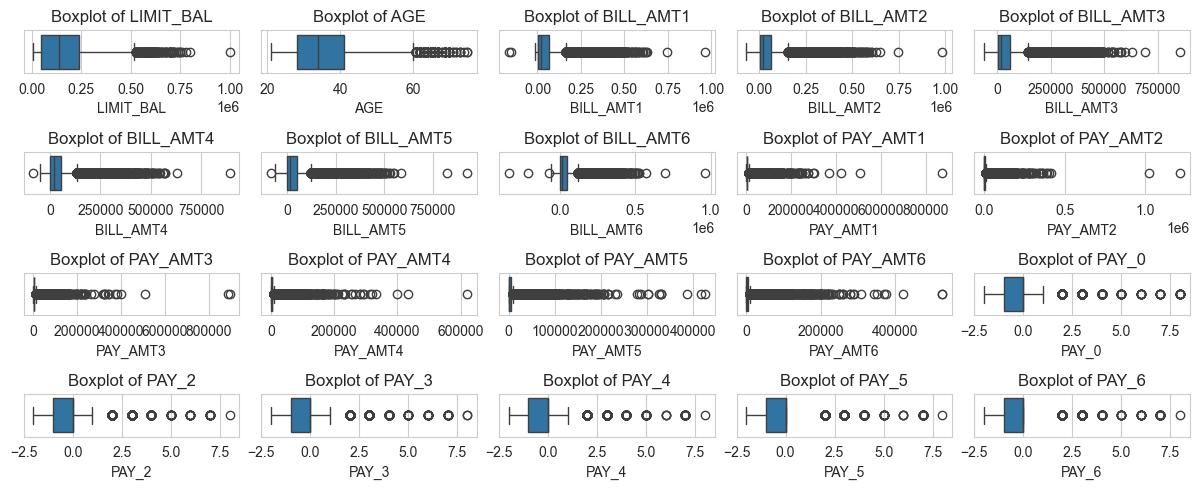

In [18]:
distribution_plot(4, 5, X_train_raw, numeric_cols, "numeric_before_preprocessing_distribution.png")
boxplot_grid(4, 5, X_train_raw, numeric_cols, "numeric_before_preprocessing_boxplot.png")


## 13.2. Distribution and outlier checks after preprocessing

**Purpose:** Repeats distribution, outlier, and normality checks on transformed continuous variables.

**Key result:** The before/after comparison shows how capping, transformation, and scaling changed the data.



=== Test Normality Before Preprocessing with Shapiro-Wilk ===
Running normality test:
LIMIT_BAL: Shapiro-Wilk test p-value = 0.0000. Reject normality.
AGE: Shapiro-Wilk test p-value = 0.0000. Reject normality.
BILL_AMT1: Shapiro-Wilk test p-value = 0.0000. Reject normality.
BILL_AMT2: Shapiro-Wilk test p-value = 0.0000. Reject normality.
BILL_AMT3: Shapiro-Wilk test p-value = 0.0000. Reject normality.
BILL_AMT4: Shapiro-Wilk test p-value = 0.0000. Reject normality.
BILL_AMT5: Shapiro-Wilk test p-value = 0.0000. Reject normality.
BILL_AMT6: Shapiro-Wilk test p-value = 0.0000. Reject normality.
PAY_AMT1: Shapiro-Wilk test p-value = 0.0000. Reject normality.
PAY_AMT2: Shapiro-Wilk test p-value = 0.0000. Reject normality.
PAY_AMT3: Shapiro-Wilk test p-value = 0.0000. Reject normality.
PAY_AMT4: Shapiro-Wilk test p-value = 0.0000. Reject normality.
PAY_AMT5: Shapiro-Wilk test p-value = 0.0000. Reject normality.
PAY_AMT6: Shapiro-Wilk test p-value = 0.0000. Reject normality.

=== Test Norma

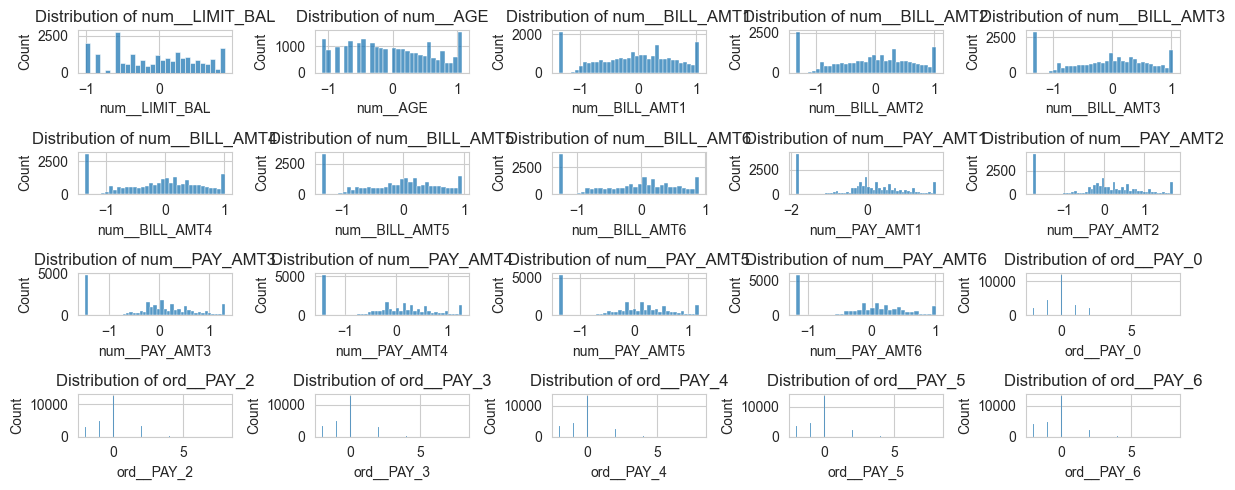

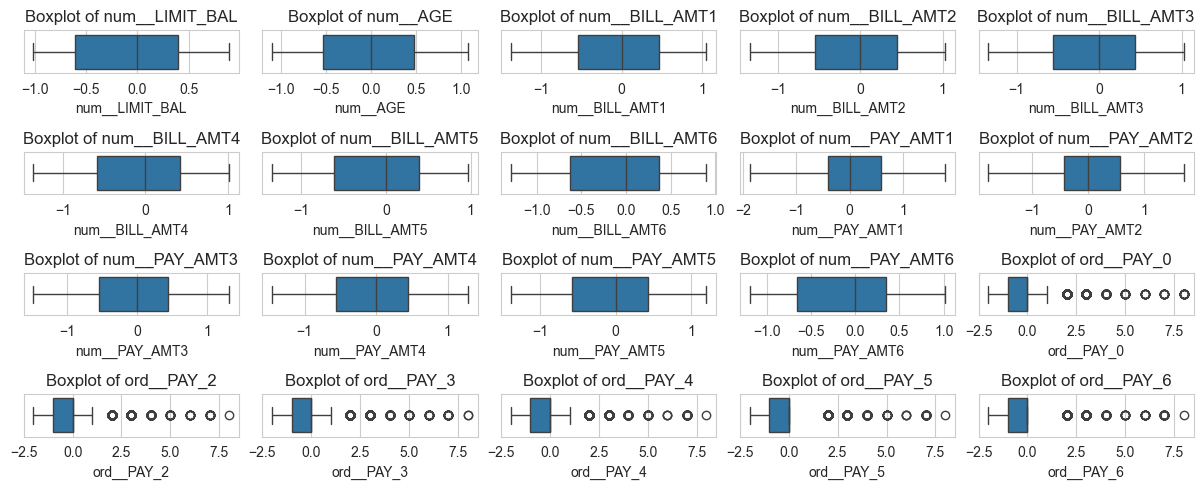


=== Preprocessed Data Shapes ===
Train shape: (24000, 31)
Test shape: (6000, 31)


In [19]:
numeric_transformed_cols = [col for col in X_train_df.columns if col.startswith("num__") or col.startswith("ord__")]
# Before preprocessing
print("\n=== Test Normality Before Preprocessing with Shapiro-Wilk ===")
test_normality(X_train_raw, continuous_cols)
# After preprocessing
continuous_transformed_cols = [f"num__{col}" for col in continuous_cols]
print("\n=== Test Normality After Preprocessing with Shapiro-Wilk ===")
test_normality(X_train_df, continuous_transformed_cols)

distribution_plot(4, 5, X_train_df, numeric_transformed_cols, "numeric_after_preprocessing_distribution.png")
boxplot_grid(4, 5, X_train_df, numeric_transformed_cols, "numeric_after_preprocessing_boxplot.png")


print("\n=== Preprocessed Data Shapes ===")
print(f"Train shape: {X_train_df.shape}")
print(f"Test shape: {X_test_df.shape}")

# Transform full data with the fitted preprocessor.
X_full = preprocessor.transform(X)
X_full_df = pd.DataFrame(X_full, columns=feature_names, index=X.index)


## 14. Simple Logistic Regression baseline

**Purpose:** Fits an untuned Logistic Regression model on the standard preprocessed train set.

**Key result:** Accuracy, ROC-AUC, average precision, the confusion matrix, and the classification report establish a baseline.


In [20]:
baseline_log = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,)
baseline_log.fit(X_train, y_train)

baseline_test_pred = baseline_log.predict(X_test)
baseline_test_probs = baseline_log.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION - SIMPLE BASELINE")
print("=" * 60)
print(f"Test Accuracy: {accuracy_score(y_test, baseline_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, baseline_test_probs):.4f}")
print(f"Average Precision: {average_precision_score(y_test, baseline_test_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, baseline_test_pred, zero_division=0))



LOGISTIC REGRESSION - SIMPLE BASELINE
Test Accuracy: 0.8033
ROC-AUC: 0.7355
Average Precision: 0.4971

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      4673
           1       0.64      0.25      0.36      1327

    accuracy                           0.80      6000
   macro avg       0.73      0.60      0.62      6000
weighted avg       0.78      0.80      0.77      6000



## 14.1. Baseline Logistic Regression threshold comparison

**Purpose:** Evaluates baseline probabilities at thresholds 0.3, 0.5, and 0.7 on the untouched test set.

**Key result:** The table makes the precision-recall and operational trade-offs explicit.


In [21]:
# Fixed thresholds are reported on the test set only for comparison.
baseline_thresholds = [0.3, 0.5, 0.7]
baseline_threshold_results = []

for threshold in baseline_thresholds:
    baseline_pred_threshold = apply_threshold(baseline_test_probs, threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, baseline_pred_threshold).ravel()

    if threshold == 0.3:
        interpretation = "Max Detection (Aggressive)"
    elif threshold == 0.5:
        interpretation = "Standard (Default)"
    else:
        interpretation = "Reduce Operations (Conservative)"

    baseline_threshold_results.append({"Threshold": threshold, "Precision": precision_score(y_test, baseline_pred_threshold, zero_division=0), "Recall": recall_score(y_test, baseline_pred_threshold, zero_division=0), "F1-Score": f1_score(y_test, baseline_pred_threshold, zero_division=0), "TP": tp, "FP": fp, "FN": fn, "TN": tn, "Interpretation": interpretation,})

baseline_threshold_results_df = pd.DataFrame(baseline_threshold_results)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.precision", 4)

print("\n=== Simple Baseline Logistic Threshold Comparison ===")
print(baseline_threshold_results_df.round(4).to_string(index=False))



=== Simple Baseline Logistic Threshold Comparison ===
 Threshold  Precision  Recall  F1-Score  TP  FP   FN   TN                   Interpretation
       0.3     0.5197  0.5072    0.5133 673 622  654 4051       Max Detection (Aggressive)
       0.5     0.6450  0.2464    0.3566 327 180 1000 4493               Standard (Default)
       0.7     0.7424  0.0739    0.1343  98  34 1229 4639 Reduce Operations (Conservative)


## 15. Optimized Logistic Regression with SMOTENC

**Purpose:** Tunes Logistic Regression regularization with Optuna inside a leakage-safe SMOTENC pipeline, then refits the selected model on the full training set.

**Key result:** Validation probabilities define Low, Medium, and High risk boundaries; test metrics and cross-validation assess the final model.


[I 2026-09-02 14:28:21,393] A new study created in memory with name: no-name-93c4fe0e-e3a5-4296-828a-bc202b60eb45
[I 2026-09-02 14:28:34,899] Trial 0 finished with value: 0.7739110672372015 and parameters: {'C': 0.03148911647956861}. Best is trial 0 with value: 0.7739110672372015.
[I 2026-09-02 14:28:50,116] Trial 1 finished with value: 0.7706571809222073 and parameters: {'C': 6.351221010640703}. Best is trial 0 with value: 0.7739110672372015.
[I 2026-09-02 14:29:04,989] Trial 2 finished with value: 0.7713136381839939 and parameters: {'C': 0.8471801418819978}. Best is trial 0 with value: 0.7739110672372015.
[I 2026-09-02 14:29:19,026] Trial 3 finished with value: 0.7720354894997834 and parameters: {'C': 0.24810409748678125}. Best is trial 0 with value: 0.7739110672372015.
[I 2026-09-02 14:29:31,119] Trial 4 finished with value: 0.7739615466422392 and parameters: {'C': 0.004207988669606638}. Best is trial 4 with value: 0.7739615466422392.
[I 2026-09-02 14:29:44,056] Trial 5 finished wit


=== Best Logistic Regression Parameters ===
{'C': 0.011493777630305664}
Best Cross-Validated ROC-AUC: 0.7744

=== Logistic Risk Thresholds from Validation ===
Low / Medium threshold: 0.1667
Medium / High threshold: 0.3253

=== Validation Risk Group Summary ===
risk_group  customer_count  mean_predicted_probability  observed_default_rate
       Low            2400                      0.1025                 0.1096
    Medium            1440                      0.2222                 0.1958
      High             960                      0.5072                 0.5385

LOGISTIC REGRESSION - OPTIMIZED WITH SMOTENC
Train Accuracy: 0.7527
Test Accuracy: 0.7493
Test ROC-AUC: 0.7590
Test Average Precision: 0.5201

Confusion Matrix (Test):
[[3689  984]
 [ 520  807]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.45      0.61      0.52      1327

    accuracy                       

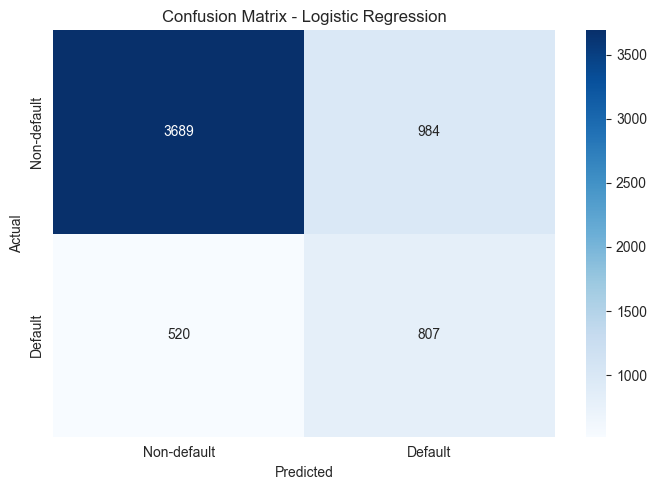


Logistic Regression 5-Fold Cross-Validation Scores:
[0.77290672 0.76737739 0.76517448 0.77748972 0.7759555 ]
Cross-Validation Mean: 0.7718


In [22]:
# Keep part of the training data only for validation.
X_log_train_raw, X_log_val_raw, y_log_train, y_log_val = train_test_split(X_train_raw, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train,)

preprocessor_smote = ColumnTransformer(transformers=[("num", Pipeline(steps=[("winsorizer", Winsorizer(capping_method="quantiles", tail="both", fold=0.05),),
    ("power", PowerTransformer(method="yeo-johnson")), ("scaler", RobustScaler()),]), continuous_cols,),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), smote_categorical_cols,),],
    verbose_feature_names_out=False,)

smote_categorical_indices = list(range(len(continuous_cols), len(continuous_cols) + len(smote_categorical_cols)))

postprocessor_smote = ColumnTransformer(transformers=[("num", "passthrough", list(range(len(continuous_cols)))),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), smote_categorical_indices,),],
    verbose_feature_names_out=False,)


def logistic_objective(trial):
    c_value = trial.suggest_float("C", 0.001, 10, log=True)
    logistic_model = ImbPipeline(steps=[("preprocessor_smote", clone(preprocessor_smote)),
        ("smotenc", SMOTENC(categorical_features=smote_categorical_indices, random_state=RANDOM_STATE)),
        ("postprocessor_smote", clone(postprocessor_smote)),
        ("model", LogisticRegression(C=c_value, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(logistic_model, X_log_train_raw, y_log_train, cv=skf, scoring="roc_auc").mean()


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),)
study.optimize(logistic_objective, n_trials=20)
best_params = study.best_params

print("\n=== Best Logistic Regression Parameters ===")
print(best_params)
print(f"Best Cross-Validated ROC-AUC: {study.best_value:.4f}")

# Learn probability-based risk boundaries without oversampling.
risk_model_val = Pipeline(steps=[("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),])
risk_model_val.fit(X_log_train_raw, y_log_train)

y_val_probs = risk_model_val.predict_proba(X_log_val_raw)[:, 1]

# Risk boundaries are learned from validation probabilities.
# Low Risk = lower 50%, High Risk = top 20% of validation risk.
low_risk_threshold = float(np.quantile(y_val_probs, 0.50))
high_risk_threshold = float(np.quantile(y_val_probs, 0.80))

logistic_risk_bins = [0.0, low_risk_threshold, high_risk_threshold, 1.0]
logistic_risk_labels = ["Low", "Medium", "High"]

print("\n=== Logistic Risk Thresholds from Validation ===")
print(f"Low / Medium threshold: {low_risk_threshold:.4f}")
print(f"Medium / High threshold: {high_risk_threshold:.4f}")

validation_risk_groups = pd.cut(y_val_probs, bins=logistic_risk_bins, labels=logistic_risk_labels, include_lowest=True,)

validation_risk_summary = pd.DataFrame({"predicted_probability": y_val_probs, "risk_group": validation_risk_groups, "observed_default": y_log_val.to_numpy(),})

validation_risk_summary = (validation_risk_summary.groupby("risk_group", observed=True).agg(customer_count=("risk_group", "size"), mean_predicted_probability=("predicted_probability", "mean"), observed_default_rate=("observed_default", "mean"),).reset_index())

print("\n=== Validation Risk Group Summary ===")
print(validation_risk_summary.to_string(index=False))

# Refit the final SMOTENC logistic model on the complete training set.
model_log = ImbPipeline(steps=[("preprocessor_smote", clone(preprocessor_smote)),
    ("smotenc", SMOTENC(categorical_features=smote_categorical_indices, random_state=RANDOM_STATE)),
    ("postprocessor_smote", clone(postprocessor_smote)),
    ("model", LogisticRegression(**study.best_params, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),])
model_log.fit(X_train_raw, y_train)

y_train_pred = model_log.predict(X_train_raw)
y_test_pred = model_log.predict(X_test_raw)
y_train_probs = model_log.predict_proba(X_train_raw)[:, 1]
y_test_probs = model_log.predict_proba(X_test_raw)[:, 1]

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION - OPTIMIZED WITH SMOTENC")
print("=" * 60)
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_probs):.4f}")
print(f"Test Average Precision: {average_precision_score(y_test, y_test_probs):.4f}")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, zero_division=0))

cm_log = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-default", "Default"], yticklabels=["Non-default", "Default"],)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../figures/logistic_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

skf_log = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_model_log = ImbPipeline(steps=[("preprocessor_smote", clone(preprocessor_smote)),
    ("smotenc", SMOTENC(categorical_features=smote_categorical_indices, random_state=RANDOM_STATE)),
    ("postprocessor_smote", clone(postprocessor_smote)),
    ("model", LogisticRegression(C=best_params["C"], solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE)),])

cross_val_log = cross_val_score(cv_model_log, X_train_raw, y_train, cv=skf_log, scoring="roc_auc")

print("\nLogistic Regression 5-Fold Cross-Validation Scores:")
print(cross_val_log)
print(f"Cross-Validation Mean: {cross_val_log.mean():.4f}")


## 16. Logistic Regression threshold comparison

**Purpose:** Applies thresholds 0.3, 0.5, and 0.7 to the optimized model's test probabilities.

**Key result:** Precision, recall, F1, and confusion-matrix counts quantify aggressive, standard, and conservative policies.


In [23]:
# Fixed thresholds are reported on the test set only for comparison.
logistic_thresholds = [0.3, 0.5, 0.7]
logistic_threshold_results = []

for threshold in logistic_thresholds:
    y_pred_threshold = apply_threshold(y_test_probs, threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    if threshold == 0.3:
        interpretation = "Max Detection (Aggressive)"
    elif threshold == 0.5:
        interpretation = "Standard (Default)"
    else:
        interpretation = "Reduce Operations (Conservative)"

    logistic_threshold_results.append({"Threshold": threshold, "Precision": precision_score(y_test, y_pred_threshold, zero_division=0), "Recall": recall_score(y_test, y_pred_threshold, zero_division=0), "F1-Score": f1_score(y_test, y_pred_threshold, zero_division=0), "TP": tp, "FP": fp, "FN": fn, "TN": tn, "Interpretation": interpretation,})

logistic_threshold_results_df = pd.DataFrame(logistic_threshold_results)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.precision", 4)

print("\n=== Logistic Threshold Comparison ===")
print(logistic_threshold_results_df.round(4).to_string(index=False))



=== Logistic Threshold Comparison ===
 Threshold  Precision  Recall  F1-Score   TP   FP  FN   TN                   Interpretation
       0.3     0.2802  0.8862    0.4258 1176 3021 151 1652       Max Detection (Aggressive)
       0.5     0.4506  0.6081    0.5176  807  984 520 3689               Standard (Default)
       0.7     0.6223  0.4084    0.4932  542  329 785 4344 Reduce Operations (Conservative)


## 17. Logistic Regression ROC and Precision-Recall curves

**Purpose:** Plots ROC and Precision-Recall curves for the optimized Logistic Regression model.

**Key result:** ROC-AUC and average precision summarize ranking quality under class imbalance.


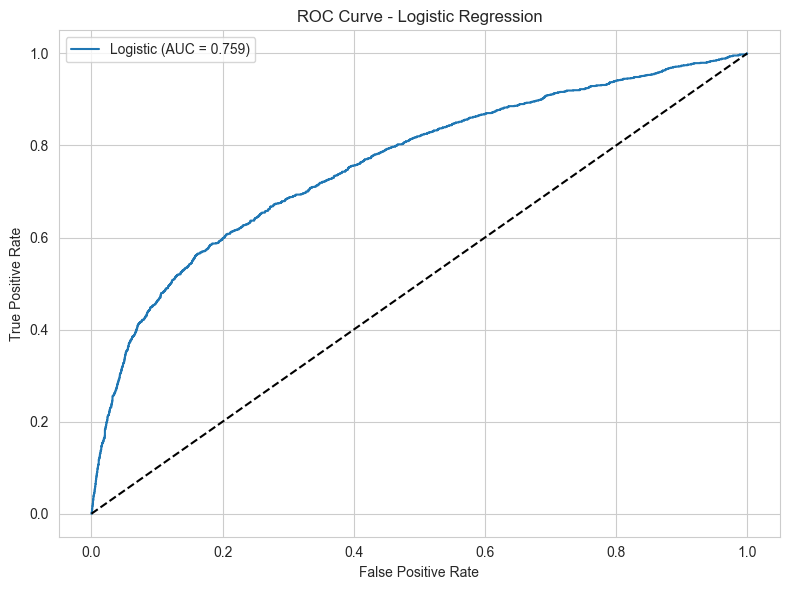

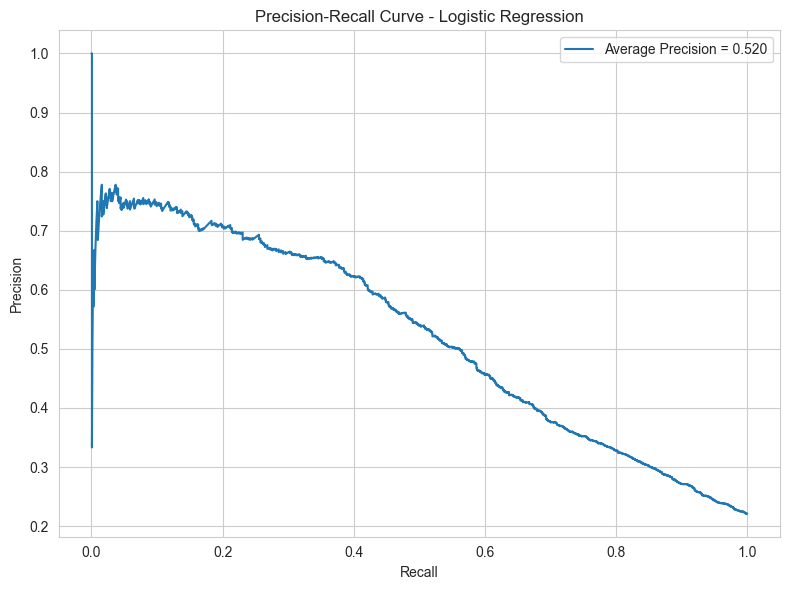

In [24]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_test_probs)
auc_log = roc_auc_score(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/logistic_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

precision_log, recall_log, _ = precision_recall_curve(y_test, y_test_probs)
avg_precision_log = average_precision_score(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_log, precision_log, label=f"Average Precision = {avg_precision_log:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/logistic_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 18. Logistic Regression coefficients and SHAP

**Purpose:** Reconstructs transformed feature names, ranks signed model coefficients, and calculates Linear SHAP values on a reproducible sample.

**Key result:** Coefficient and SHAP plots show both feature importance and the direction of default-risk effects.



=== Top Logistic Regression Coefficients ===
                  feature  coefficient  abs_coefficient
                  PAY_0_2       1.1902           1.1902
                  PAY_0_0      -0.6185           0.6185
        EDUCATION_Unknown      -0.5101           0.5101
                 PAY_0_-2      -0.5025           0.5025
     EDUCATION_University       0.4662           0.4662
                LIMIT_BAL      -0.4453           0.4453
                BILL_AMT6       0.3958           0.3958
                BILL_AMT3       0.3354           0.3354
                BILL_AMT2       0.3262           0.3262
EDUCATION_Graduate School       0.3076           0.3076
                BILL_AMT1      -0.2981           0.2981
         MARRIAGE_Married       0.2783           0.2783
                 PAY_AMT2      -0.2685           0.2685
          MARRIAGE_Others      -0.2449           0.2449
                 PAY_AMT5      -0.2413           0.2413


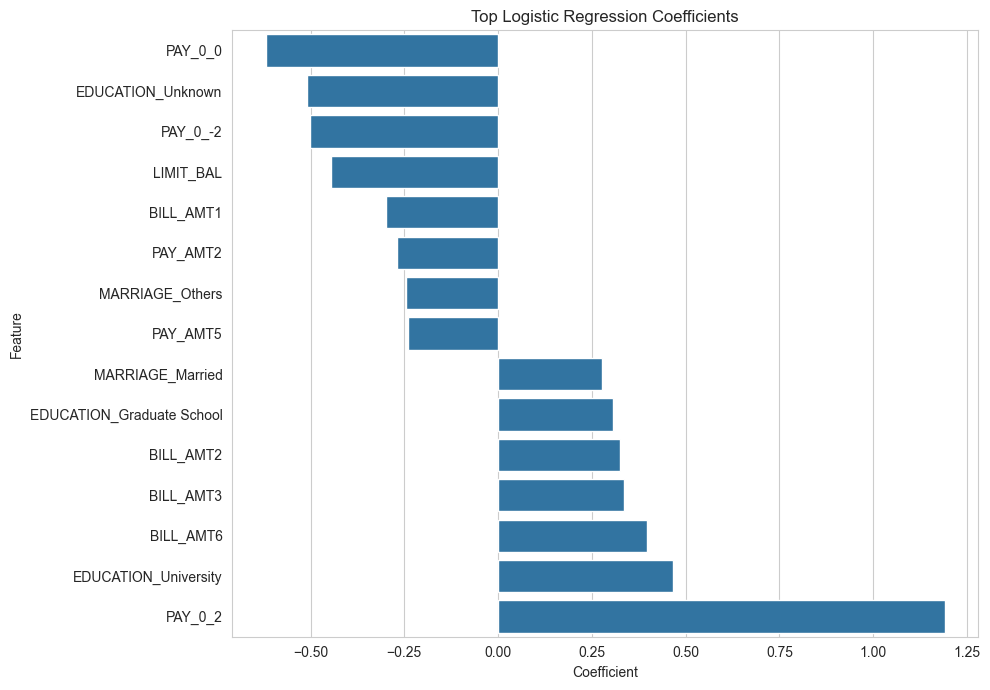

Background dataset has 5000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5000 when initializing the masker.



=== SHAP Feature Importance - Logistic Regression ===
                  feature  importance
                  PAY_0_0      0.3091
     EDUCATION_University      0.2312
                BILL_AMT6      0.2309
                 PAY_AMT2      0.2230
                LIMIT_BAL      0.2136
                BILL_AMT3      0.2017
                 PAY_AMT1      0.1945
                BILL_AMT2      0.1912
                 PAY_AMT3      0.1719
                  PAY_0_2      0.1715
                BILL_AMT1      0.1715
                 PAY_AMT5      0.1649
EDUCATION_Graduate School      0.1486
         MARRIAGE_Married      0.1362
                BILL_AMT4      0.1299


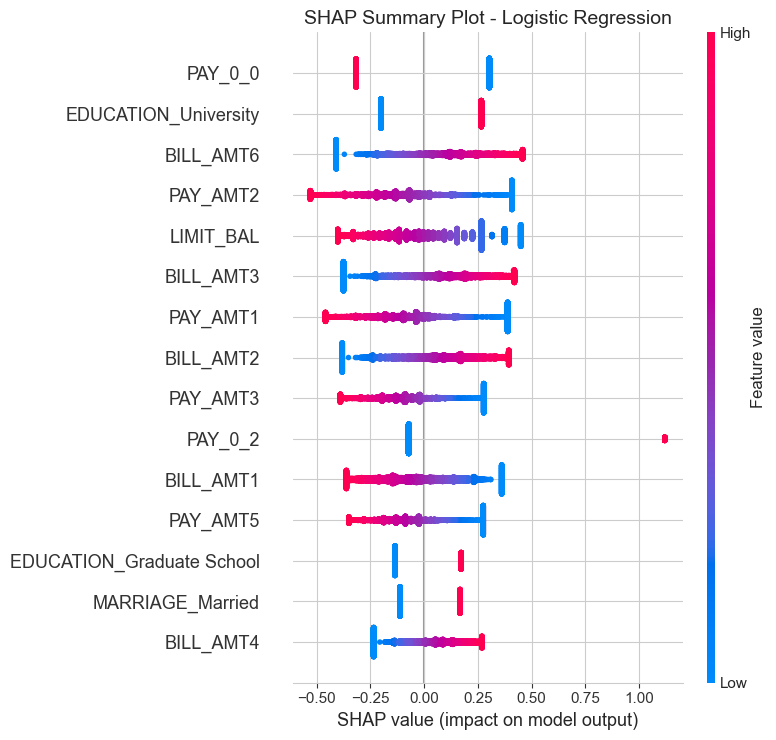

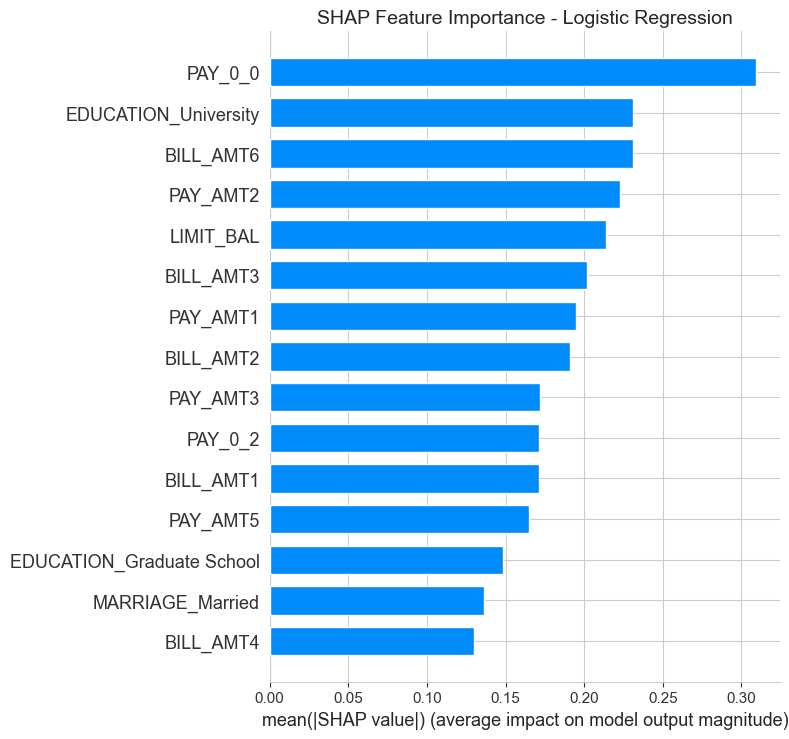


=== SHAP Direction for Top 5 Logistic Features ===
             feature  coefficient                                     direction
             PAY_0_0      -0.6185 Higher values decrease predicted default risk
EDUCATION_University       0.4662 Higher values increase predicted default risk
           BILL_AMT6       0.3958 Higher values increase predicted default risk
            PAY_AMT2      -0.2685 Higher values decrease predicted default risk
           LIMIT_BAL      -0.4453 Higher values decrease predicted default risk


In [25]:
logistic_model_fitted = model_log.named_steps["model"]
logistic_preprocessor_fitted = model_log.named_steps["preprocessor_smote"]
logistic_postprocessor_fitted = model_log.named_steps["postprocessor_smote"]
X_train_log_preprocessed = logistic_preprocessor_fitted.transform(X_train_raw)
X_train_log = logistic_postprocessor_fitted.transform(X_train_log_preprocessed)

logistic_onehot_fitted = logistic_postprocessor_fitted.named_transformers_["cat"]
logistic_ordinal_fitted = logistic_preprocessor_fitted.named_transformers_["cat"]
logistic_categorical_feature_names = []

for column, encoded_values, original_values in zip(smote_categorical_cols, logistic_onehot_fitted.categories_, logistic_ordinal_fitted.categories_):
    for encoded_value in encoded_values:
        original_value = original_values[int(encoded_value)]
        logistic_categorical_feature_names.append(f"{column}_{original_value}")

feature_names_log = np.asarray([*continuous_cols, *logistic_categorical_feature_names])

coefficient_df = pd.DataFrame({"feature": feature_names_log, "coefficient": logistic_model_fitted.coef_[0],})
coefficient_df["abs_coefficient"] = coefficient_df["coefficient"].abs()
coefficient_df = coefficient_df.sort_values("abs_coefficient", ascending=False)

print("\n=== Top Logistic Regression Coefficients ===")
print(coefficient_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 7))
top_coefficients = coefficient_df.head(15).sort_values("coefficient")
sns.barplot(data=top_coefficients, x="coefficient", y="feature", orient="h")
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../figures/logistic_top_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

logistic_shap_size = min(5000, len(X_train_log))
logistic_shap_rng = np.random.default_rng(RANDOM_STATE)
logistic_shap_indices = logistic_shap_rng.choice(len(X_train_log), size=logistic_shap_size, replace=False)
X_train_log_shap = X_train_log[logistic_shap_indices]

explainer_log = shap.LinearExplainer(logistic_model_fitted, X_train_log_shap)
shap_values_log = explainer_log.shap_values(X_train_log_shap)

shap_importance_log = pd.DataFrame({"feature": feature_names_log, "importance": np.abs(shap_values_log).mean(axis=0),}).sort_values("importance", ascending=False)

print("\n=== SHAP Feature Importance - Logistic Regression ===")
print(shap_importance_log.head(15).to_string(index=False))

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_log, X_train_log_shap, feature_names=feature_names_log, max_display=15, show=False,)
plt.title("SHAP Summary Plot - Logistic Regression", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/logistic_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_log, X_train_log_shap, feature_names=feature_names_log, plot_type="bar", max_display=15, show=False,)
plt.title("SHAP Feature Importance - Logistic Regression", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/logistic_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

logistic_top5 = shap_importance_log.head(5)["feature"].values
logistic_shap_direction = coefficient_df.set_index("feature").loc[logistic_top5, ["coefficient"]].reset_index()
logistic_shap_direction["direction"] = np.where(logistic_shap_direction["coefficient"] > 0, "Higher values increase predicted default risk", "Higher values decrease predicted default risk")

print("\n=== SHAP Direction for Top 5 Logistic Features ===")
print(logistic_shap_direction.to_string(index=False))


## 19. RFE with Logistic Regression

**Purpose:** Runs recursive feature elimination with the tuned Logistic Regression estimator.

**Key result:** The final ranking offers a second, model-based view of feature relevance.


In [26]:
log_reg_rfe = LogisticRegression(C=best_params["C"], solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE,)

rfe_log = RFE(estimator=log_reg_rfe, n_features_to_select=1, step=1,)
rfe_log.fit(X_train_log, y_train)

rfe_ranking_log = pd.DataFrame({"feature": feature_names_log, "ranking": rfe_log.ranking_,}).sort_values("ranking").reset_index(drop=True)

rfe_ranking_log["rank"] = range(1, len(rfe_ranking_log) + 1)

print("\n=== RFE Feature Ranking - Logistic Regression ===")
print(rfe_ranking_log[["rank", "feature", "ranking"]].to_string(index=False))



=== RFE Feature Ranking - Logistic Regression ===
 rank                   feature  ranking
    1                   PAY_0_2        1
    2                   PAY_4_2        2
    3                   PAY_0_0        3
    4                  PAY_0_-2        4
    5                  PAY_0_-1        5
    6                   PAY_0_3        6
    7                 LIMIT_BAL        7
    8                   PAY_5_2        8
    9                  PAY_AMT2        9
   10                 BILL_AMT3       10
   11         EDUCATION_Unknown       11
   12                   PAY_3_2       12
   13                  PAY_AMT1       13
   14                 BILL_AMT2       14
   15                   PAY_6_0       15
   16                  PAY_3_-2       16
   17                  PAY_AMT3       17
   18                 BILL_AMT6       18
   19                  PAY_AMT5       19
   20           MARRIAGE_Single       20
   21                  PAY_2_-1       21
   22                  PAY_4_-2       22
   23 

# Part IV — Dimensionality reduction and customer clustering

This part compares projection methods, learns UMAP + GMM customer clusters, profiles them, and saves the cluster outputs.


## 20. PCA, UMAP, and t-SNE comparison on full dataset

**Purpose:** Projects the fully preprocessed dataset into two dimensions with PCA, UMAP, and t-SNE.

**Key result:** Side-by-side target-colored plots compare linear and nonlinear class structure.


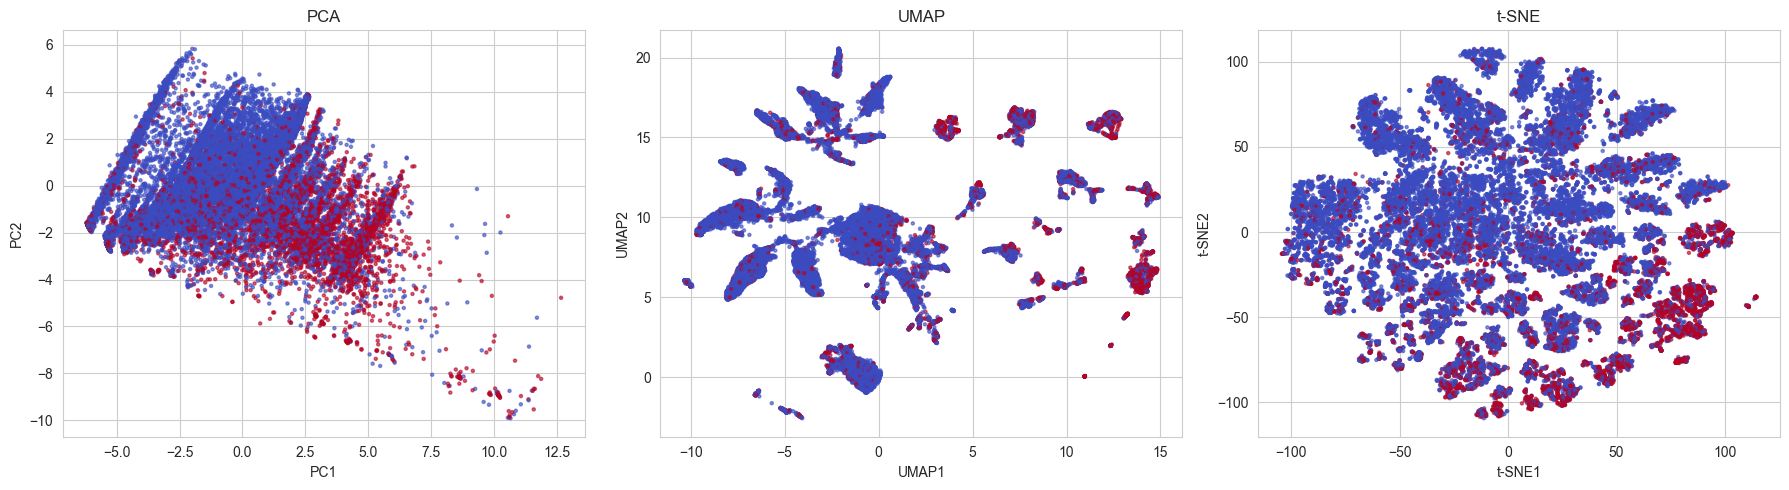

In [30]:
# Use a separate preprocessor for full-dataset visualization.
preprocessor_vis = clone(preprocessor)
X_preprocessed = preprocessor_vis.fit_transform(X)

target_for_visualization = y.to_numpy()

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_preprocessed)

# UMAP
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_STATE, n_jobs=1)
X_umap = umap_reducer.fit_transform(X_preprocessed)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
X_tsne = tsne.fit_transform(X_preprocessed)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=target_for_visualization, cmap="coolwarm", s=5, alpha=0.6)
axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=target_for_visualization, cmap="coolwarm", s=5, alpha=0.6)
axes[1].set_title("UMAP")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=target_for_visualization, cmap="coolwarm", s=5, alpha=0.6)
axes[2].set_title("t-SNE")
axes[2].set_xlabel("t-SNE1")
axes[2].set_ylabel("t-SNE2")

plt.tight_layout()
plt.savefig("../figures/pca_umap_tsne_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 21. Optional UMAP + GMM hyperparameter tuning

**Purpose:** Provides an optional Optuna objective for selecting UMAP and Gaussian Mixture parameters using silhouette score.

**Key result:** The block remains commented out by default because it is computationally expensive; the recorded best parameters are used next.


In [ ]:
# Optional tuning block.
# Parameters from the original experiment.
#
# def cluster_objective(trial):
#     n_neighbors = trial.suggest_int("n_neighbors", 10, 80)
#     min_dist = trial.suggest_float("min_dist", 0.0, 0.5)
#     n_components = trial.suggest_int("n_components", 2, 8)
#     covariance_type = trial.suggest_categorical("covariance_type", ["full", "tied", "diag"])
#
#     umap_model = umap.UMAP(
#         n_neighbors=n_neighbors,
#         min_dist=min_dist,
#         n_components=n_components,
#         random_state=RANDOM_STATE,
#     )
#     X_umap_trial = umap_model.fit_transform(X_train_df)
#
#     gmm_model = GaussianMixture(
#         n_components=3,
#         covariance_type=covariance_type,
#         random_state=RANDOM_STATE,
#     )
#     labels_trial = gmm_model.fit_predict(X_umap_trial)
#
#     if len(set(labels_trial)) < 2:
#         return -1.0
#
#     return silhouette_score(X_umap_trial, labels_trial)
#
# cluster_study = optuna.create_study(direction="maximize")
# cluster_study.optimize(cluster_objective, n_trials=20)
# print(f"Best Silhouette: {cluster_study.best_value:.4f}")
# print(cluster_study.best_params)


## 22. UMAP + GMM clustering

**Purpose:** Fits UMAP on training features, transforms test features, and learns three Gaussian Mixture clusters without using test labels.

**Key result:** Silhouette scores, cluster distributions, and training default rates define the Low-, Medium-, and High-Risk cluster mapping.


In [31]:
umap_final = umap.UMAP(n_neighbors=44, min_dist=0.0027571032141944507, n_components=3, random_state=RANDOM_STATE, n_jobs=1,)

X_train_umap = umap_final.fit_transform(X_train_df)
X_test_umap = umap_final.transform(X_test_df)

gmm_final = GaussianMixture(n_components=3, covariance_type="full", random_state=RANDOM_STATE,)

train_labels = gmm_final.fit_predict(X_train_umap)
test_labels = gmm_final.predict(X_test_umap)

train_silhouette = silhouette_score(X_train_umap, train_labels, sample_size=min(5000, len(X_train_umap)), random_state=RANDOM_STATE)
test_silhouette = silhouette_score(X_test_umap, test_labels, sample_size=min(5000, len(X_test_umap)), random_state=RANDOM_STATE)

print("\n=== UMAP + GMM Clustering ===")
print(f"Train Silhouette Score: {train_silhouette:.4f}")
print(f"Test Silhouette Score: {test_silhouette:.4f}")

print("\nTrain cluster distribution:")
print(pd.Series(train_labels).value_counts().sort_index())

print("\nTest cluster distribution:")
print(pd.Series(test_labels).value_counts().sort_index())

X_train_clustered = X_train_df.copy()
X_test_clustered = X_test_df.copy()

X_train_clustered["cluster_label"] = train_labels
X_test_clustered["cluster_label"] = test_labels

train_cluster_default = pd.DataFrame({"cluster_label": train_labels, "default": y_train.to_numpy(),})

default_rates_train = train_cluster_default.groupby("cluster_label")["default"].mean()
sorted_clusters_train = default_rates_train.sort_values().index.tolist()

risk_map_train = {sorted_clusters_train[0]: "Low Risk", sorted_clusters_train[1]: "Medium Risk", sorted_clusters_train[2]: "High Risk",}

X_train_clustered["risk_label"] = X_train_clustered["cluster_label"].map(risk_map_train)
X_test_clustered["risk_label"] = X_test_clustered["cluster_label"].map(risk_map_train)

print("\nDefault rate per cluster (Train):")
for cluster in sorted_clusters_train:
    print(f"Cluster {cluster} ({risk_map_train[cluster]}): {default_rates_train[cluster]:.2%}")

test_cluster_default = pd.DataFrame({"cluster_label": test_labels, "default": y_test.to_numpy(),})
default_rates_test = test_cluster_default.groupby("cluster_label")["default"].mean()

X_test_clustered["risk_label_test"] = X_test_clustered["cluster_label"].map(risk_map_train)

print("\nDefault rate per cluster (Test, reporting only):")
for cluster in sorted_clusters_train:
    print(f"Cluster {cluster} ({risk_map_train[cluster]}): {default_rates_test.get(cluster, np.nan):.2%}")



=== UMAP + GMM Clustering ===
Train Silhouette Score: 0.4926
Test Silhouette Score: 0.4940

Train cluster distribution:
0    9397
1    6340
2    8263
Name: count, dtype: int64

Test cluster distribution:
0    2391
1    1546
2    2063
Name: count, dtype: int64

Default rate per cluster (Train):
Cluster 0 (Low Risk): 10.32%
Cluster 2 (Medium Risk): 16.06%
Cluster 1 (High Risk): 47.51%

Default rate per cluster (Test, reporting only):
Cluster 0 (Low Risk): 11.25%
Cluster 2 (Medium Risk): 16.72%
Cluster 1 (High Risk): 46.12%


## 23. Combine cluster labels with original modeling columns

**Purpose:** Reattaches train and test cluster assignments to the original modeling columns while preserving row indices.

**Key result:** Validation checks and a cluster profile table summarize size, risk label, central values, and default rate for each cluster.


In [32]:
df_full = model_data.copy()

full_cluster_labels = pd.Series(index=df_full.index, dtype="int64")
full_cluster_labels.loc[X_train_raw.index] = train_labels
full_cluster_labels.loc[X_test_raw.index] = test_labels

df_full["cluster_label"] = full_cluster_labels.astype(int)
df_full["risk_label"] = df_full["cluster_label"].map(risk_map_train)

print("\n=== Cluster Label Validation ===")
print(f"Rows in df_full: {len(df_full)}")
print(f"cluster_label missing values: {df_full['cluster_label'].isna().sum()}")
print(f"risk_label missing values: {df_full['risk_label'].isna().sum()}")
print("Risk mapping learned from Train:")
print(risk_map_train)

analysis_cols = ["LIMIT_BAL", "AGE", "PAY_0", "BILL_AMT1", "PAY_AMT1", TARGET_COL,]

cluster_summary = df_full.groupby("cluster_label")[analysis_cols].agg(["mean", "median"]).round(2)
cluster_summary.columns = ["_".join(col) for col in cluster_summary.columns]
cluster_summary["cluster_size"] = df_full.groupby("cluster_label").size()
cluster_summary["risk_label"] = df_full.groupby("cluster_label")["risk_label"].first()
cluster_summary = cluster_summary.sort_values(f"{TARGET_COL}_mean")

cluster_summary_columns = ["cluster_size", "risk_label",] + [col for col in cluster_summary.columns if col not in ["cluster_size", "risk_label"]]
cluster_summary = cluster_summary[cluster_summary_columns]

print("\n=== Cluster Summary ===")
print(cluster_summary.to_string())



=== Cluster Label Validation ===
Rows in df_full: 30000
cluster_label missing values: 0
risk_label missing values: 0
Risk mapping learned from Train:
{0: 'Low Risk', 2: 'Medium Risk', 1: 'High Risk'}

=== Cluster Summary ===
               cluster_size   risk_label  LIMIT_BAL_mean  LIMIT_BAL_median  AGE_mean  AGE_median  PAY_0_mean  PAY_0_median  BILL_AMT1_mean  BILL_AMT1_median  PAY_AMT1_mean  PAY_AMT1_median  default payment next month_mean  default payment next month_median
cluster_label                                                                                                                                                                                                                                                   
0                     11788     Low Risk       165395.12          130000.0     35.13        33.0       -0.04           0.0        85620.03           55279.5        7414.18           3200.0                             0.11                                0.0
2  

## 24. Cluster visualizations

**Purpose:** Visualizes cluster membership and derived risk labels in a two-dimensional UMAP space.

**Key result:** Additional scatter plots relate clusters to recent repayment status, payment amount, and observed default.


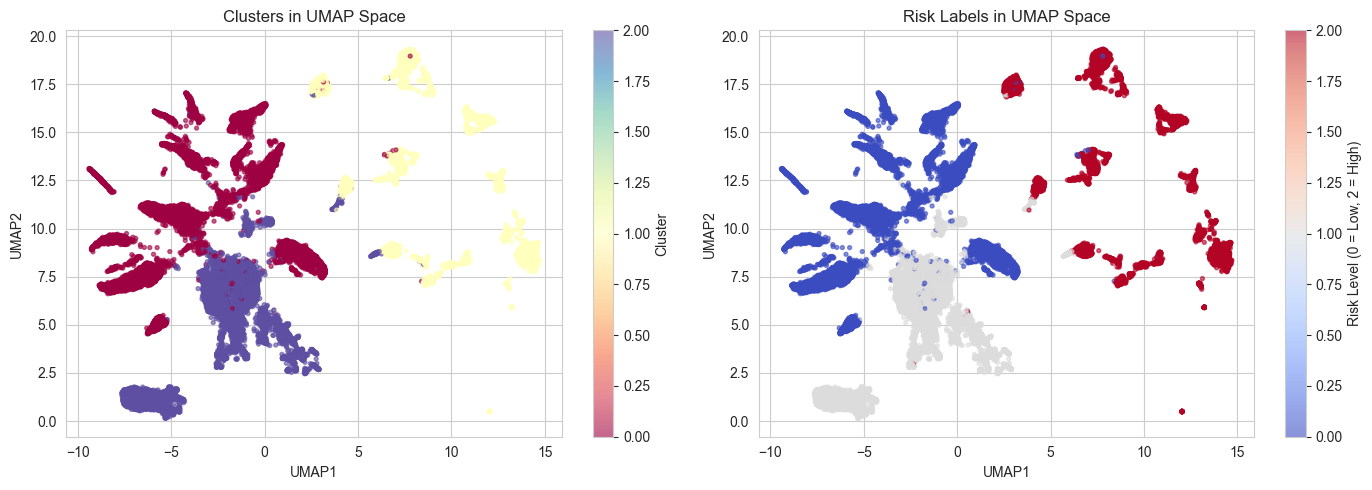

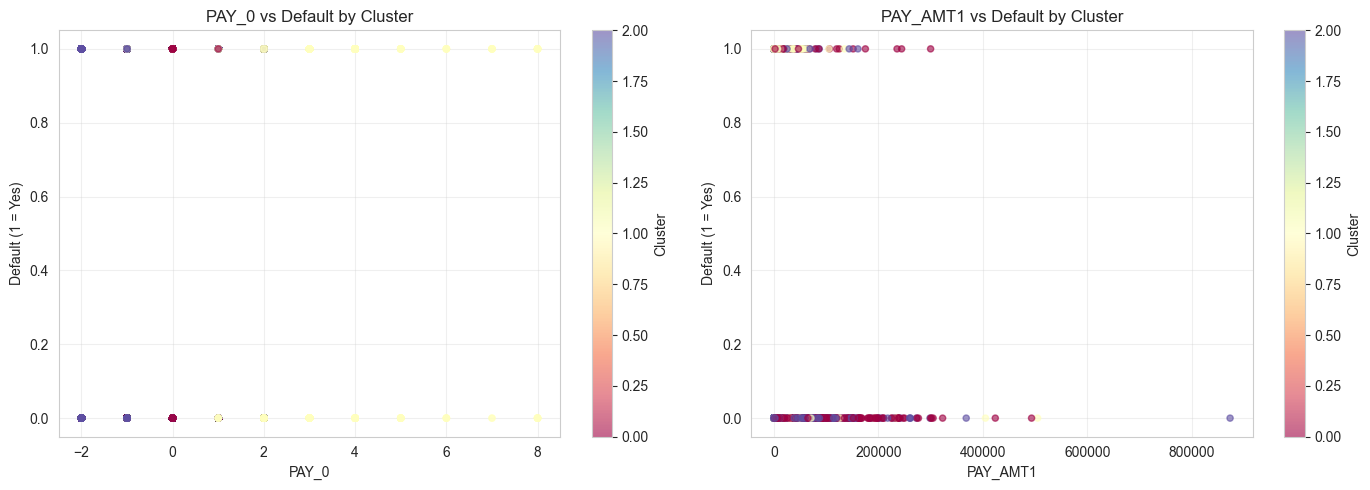

In [33]:
umap_vis = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=RANDOM_STATE, n_jobs=1,)
X_vis = umap_vis.fit_transform(X_full_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_clusters = axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=df_full["cluster_label"], cmap="Spectral", s=8, alpha=0.6,)
axes[0].set_title("Clusters in UMAP Space")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")
plt.colorbar(scatter_clusters, ax=axes[0], label="Cluster")

risk_num = df_full["risk_label"].map({"Low Risk": 0, "Medium Risk": 1, "High Risk": 2})
scatter_risk = axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=risk_num, cmap="coolwarm", s=8, alpha=0.6,)
axes[1].set_title("Risk Labels in UMAP Space")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")
plt.colorbar(scatter_risk, ax=axes[1], label="Risk Level (0 = Low, 2 = High)")

plt.tight_layout()
plt.savefig("../figures/umap_clusters_and_risk_labels.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_pay0 = axes[0].scatter(df_full["PAY_0"], df_full[TARGET_COL], c=df_full["cluster_label"], cmap="Spectral", s=20, alpha=0.6,)
axes[0].set_title("PAY_0 vs Default by Cluster")
axes[0].set_xlabel("PAY_0")
axes[0].set_ylabel("Default (1 = Yes)")
axes[0].grid(alpha=0.3)
plt.colorbar(scatter_pay0, ax=axes[0], label="Cluster")

scatter_pay_amt1 = axes[1].scatter(df_full["PAY_AMT1"], df_full[TARGET_COL], c=df_full["cluster_label"], cmap="Spectral", s=20, alpha=0.6,)
axes[1].set_title("PAY_AMT1 vs Default by Cluster")
axes[1].set_xlabel("PAY_AMT1")
axes[1].set_ylabel("Default (1 = Yes)")
axes[1].grid(alpha=0.3)
plt.colorbar(scatter_pay_amt1, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.savefig("../figures/cluster_scatter_pay0_payment_default.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 25. Save clustering outputs

**Purpose:** Exports the labeled train and test datasets and the cluster summary to Excel files.

**Key result:** The saved files make the unsupervised segmentation available for reporting and downstream analysis.


In [34]:
train_export = df_full.loc[X_train_raw.index].copy()
test_export = df_full.loc[X_test_raw.index].copy()

with pd.ExcelWriter("../cluster_dataset/clusters_train_test_final.xlsx", mode="w") as writer:
    train_export.to_excel(writer, sheet_name="Train", index=False)
    test_export.to_excel(writer, sheet_name="Test", index=False)

cluster_summary.to_excel("../cluster_dataset/cluster_summary.xlsx")

print("\n=== Saved Clustering Files ===")
print(f"Train rows: {len(train_export)}")
print(f"Test rows: {len(test_export)}")
print("clusters_train_test_final.xlsx")
print("cluster_summary.xlsx")



=== Saved Clustering Files ===
Train rows: 24000
Test rows: 6000
clusters_train_test_final.xlsx
cluster_summary.xlsx


# Part V — Random Forest cluster classifier

This part trains an interpretable supervised model to reproduce cluster assignments and evaluate High-Risk-cluster probabilities.


## 26. Random Forest model to predict GMM cluster labels

**Purpose:** Builds a supervised dataset whose target is the GMM cluster label and reuses the original train/test indices.

**Key result:** A dedicated preprocessing pipeline passes numeric and ordinal variables through and one-hot encodes nominal variables.


In [35]:
df_rf = df_full.copy()
df_rf = df_rf.drop(columns=[TARGET_COL, "risk_label"], errors="ignore")

y_rf = df_rf["cluster_label"].astype(int)
X_rf = df_rf.drop(columns=["cluster_label"])

# x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rf,)

x_train_rf = X_rf.loc[X_train_raw.index].copy()
x_test_rf = X_rf.loc[X_test_raw.index].copy()

y_train_rf = y_rf.loc[X_train_raw.index].copy()
y_test_rf = y_rf.loc[X_test_raw.index].copy()

print("\n=== Random Forest Train/Test Split ===")
print(f"Train shape: {x_train_rf.shape}, Train target shape: {y_train_rf.shape}")
print(f"Test shape: {x_test_rf.shape}, Test target shape: {y_test_rf.shape}")

preprocessor_rf = ColumnTransformer(transformers=[("num", "passthrough", continuous_cols),
            ("ord", "passthrough", ordinal_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols,),])



=== Random Forest Train/Test Split ===
Train shape: (24000, 23), Train target shape: (24000,)
Test shape: (6000, 23), Test target shape: (6000,)


## 26.1. Random Forest hyperparameter tuning with Optuna

**Purpose:** Tunes tree count, depth, split size, and leaf size with stratified cross-validated accuracy.

**Key result:** The best parameters are used to fit the final Random Forest cluster classifier.


In [36]:
def rf_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, random_state=RANDOM_STATE, n_jobs=-1)

    rf_pipeline_trial = Pipeline(steps=[("preprocessor", clone(preprocessor_rf)), ("model", rf_model),])

    skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    return cross_val_score(rf_pipeline_trial, x_train_rf, y_train_rf, cv=skf_rf, scoring="accuracy").mean()


study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(rf_objective, n_trials=20)

best_params_rf = study_rf.best_params

print("\n=== Best Random Forest Parameters ===")
print(best_params_rf)
print(f"Best Cross-Validated Accuracy: {study_rf.best_value:.4f}")


model_rf = Pipeline(steps=[("preprocessor", preprocessor_rf),
        ("model",RandomForestClassifier(
        **study_rf.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),])

model_rf.fit(x_train_rf, y_train_rf)
print("\nRandom Forest model trained successfully.")


[I 2026-09-02 15:02:18,917] A new study created in memory with name: no-name-bbb30952-5283-4792-ab4d-356fc7b51938
[I 2026-09-02 15:02:26,678] Trial 0 finished with value: 0.9884583333333333 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9884583333333333.
[I 2026-09-02 15:02:30,442] Trial 1 finished with value: 0.943875 and parameters: {'n_estimators': 89, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9884583333333333.
[I 2026-09-02 15:02:41,456] Trial 2 finished with value: 0.9877916666666666 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9884583333333333.
[I 2026-09-02 15:02:49,238] Trial 3 finished with value: 0.9758749999999999 and parameters: {'n_estimators': 258, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.988458333


=== Best Random Forest Parameters ===
{'n_estimators': 218, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1}
Best Cross-Validated Accuracy: 0.9892

Random Forest model trained successfully.


## 27. Random Forest evaluation on cluster labels

**Purpose:** Evaluates how accurately the Random Forest reproduces GMM cluster assignments on untouched test rows.

**Key result:** The section reports accuracy, class metrics, a risk-labeled confusion matrix, and five-fold cross-validation scores.



Random Forest Test Accuracy: 0.9845

Classification Report (Test):
              precision    recall  f1-score   support

    Low Risk       0.99      0.97      0.98      2391
   High Risk       0.97      0.99      0.98      1546
 Medium Risk       0.98      0.99      0.99      2063

    accuracy                           0.98      6000
   macro avg       0.98      0.99      0.98      6000
weighted avg       0.98      0.98      0.98      6000

Train Accuracy: 0.9993
Test Accuracy: 0.9845


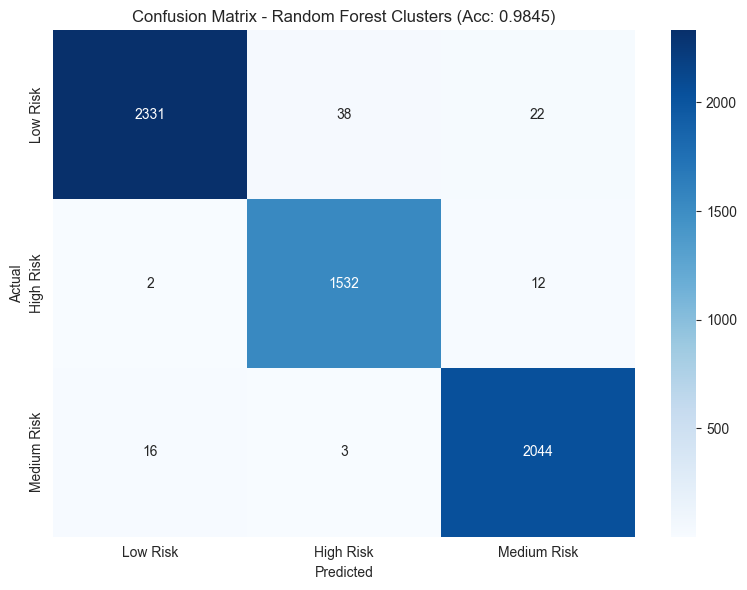


Random Forest 5-Fold Cross-Validation Scores:
[0.98791667 0.986875   0.99166667 0.98916667 0.990625  ]
Cross-Validation Mean: 0.9892


In [37]:
y_pred_rf = model_rf.predict(x_test_rf)
acc_rf = accuracy_score(y_test_rf, y_pred_rf)

rf_classes = model_rf.named_steps["model"].classes_
rf_class_names = [risk_map_train.get(int(cluster), f"Cluster {cluster}") for cluster in rf_classes]

print(f"\nRandom Forest Test Accuracy: {acc_rf:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test_rf, y_pred_rf, labels=rf_classes, target_names=rf_class_names, zero_division=0,))

print(f"Train Accuracy: {model_rf.score(x_train_rf, y_train_rf):.4f}")
print(f"Test Accuracy: {model_rf.score(x_test_rf, y_test_rf):.4f}")

cm_rf = confusion_matrix(y_test_rf, y_pred_rf, labels=rf_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=rf_class_names, yticklabels=rf_class_names,)
plt.title(f"Confusion Matrix - Random Forest Clusters (Acc: {acc_rf:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../figures/random_forest_cluster_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cross_val_rf = cross_val_score(model_rf, x_train_rf, y_train_rf, cv=skf_rf, scoring="accuracy",)

print("\nRandom Forest 5-Fold Cross-Validation Scores:")
print(cross_val_rf)
print(f"Cross-Validation Mean: {cross_val_rf.mean():.4f}")


## 28. Random Forest threshold analysis for the High Risk cluster

**Purpose:** Converts the multiclass problem into High-Risk-cluster versus all-other-clusters and tests probability thresholds 0.3, 0.5, and 0.7.

**Key result:** The comparison quantifies detection, false alarms, and operational workload at each threshold.


In [38]:
high_risk_cluster = next(cluster for cluster, risk_label in risk_map_train.items() if risk_label == "High Risk")

high_risk_class_index = list(rf_classes).index(high_risk_cluster)

y_test_probs_rf = model_rf.predict_proba(x_test_rf)[:, high_risk_class_index]
y_true_binary_rf = (y_test_rf == high_risk_cluster).astype(int)

rf_thresholds = [0.3, 0.5, 0.7]
rf_threshold_results = []

for threshold in rf_thresholds:
    y_pred_threshold = apply_threshold(y_test_probs_rf, threshold)
    tn, fp, fn, tp = confusion_matrix(y_true_binary_rf, y_pred_threshold).ravel()

    if threshold == 0.3:
        interpretation = "Max Detection (Aggressive)"
    elif threshold == 0.5:
        interpretation = "Standard (Default)"
    else:
        interpretation = "Reduce Operations (Conservative)"

    rf_threshold_results.append({"Threshold": threshold, "Precision": precision_score(y_true_binary_rf, y_pred_threshold, zero_division=0), "Recall": recall_score(y_true_binary_rf, y_pred_threshold, zero_division=0), "F1-Score": f1_score(y_true_binary_rf, y_pred_threshold, zero_division=0), "TP": tp, "FP": fp, "FN": fn, "TN": tn, "Interpretation": interpretation,})

rf_threshold_results_df = pd.DataFrame(rf_threshold_results)

print("\n=== Random Forest Threshold Comparison - High Risk Cluster ===")
print(rf_threshold_results_df.round(4).to_string(index=False))



=== Random Forest Threshold Comparison - High Risk Cluster ===
 Threshold  Precision  Recall  F1-Score   TP  FP  FN   TN                   Interpretation
       0.3     0.9692  0.9974    0.9831 1542  49   4 4405       Max Detection (Aggressive)
       0.5     0.9751  0.9890    0.9820 1529  39  17 4415               Standard (Default)
       0.7     0.9799  0.9774    0.9786 1511  31  35 4423 Reduce Operations (Conservative)


## 29. Random Forest ROC and Precision-Recall curves

**Purpose:** Plots binary ROC and Precision-Recall curves for High-Risk-cluster membership.

**Key result:** AUC and average precision summarize the quality of the cluster-membership probabilities.


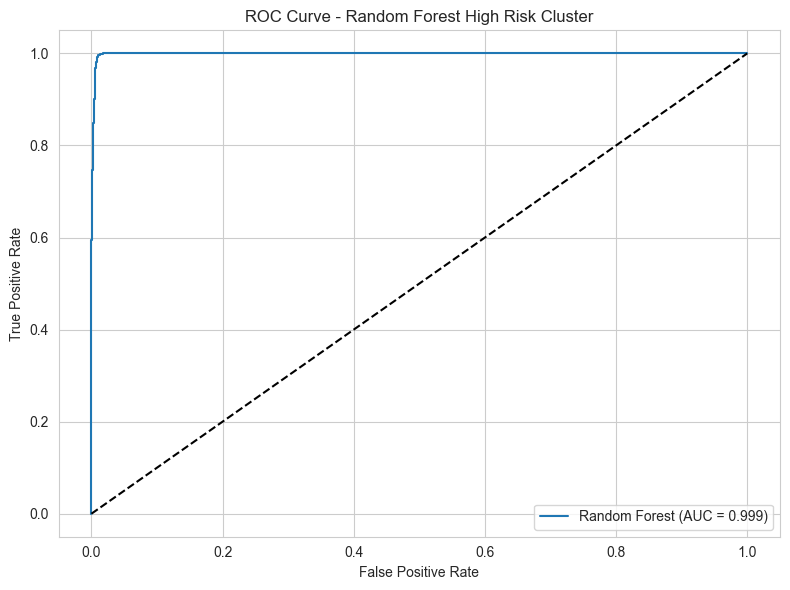

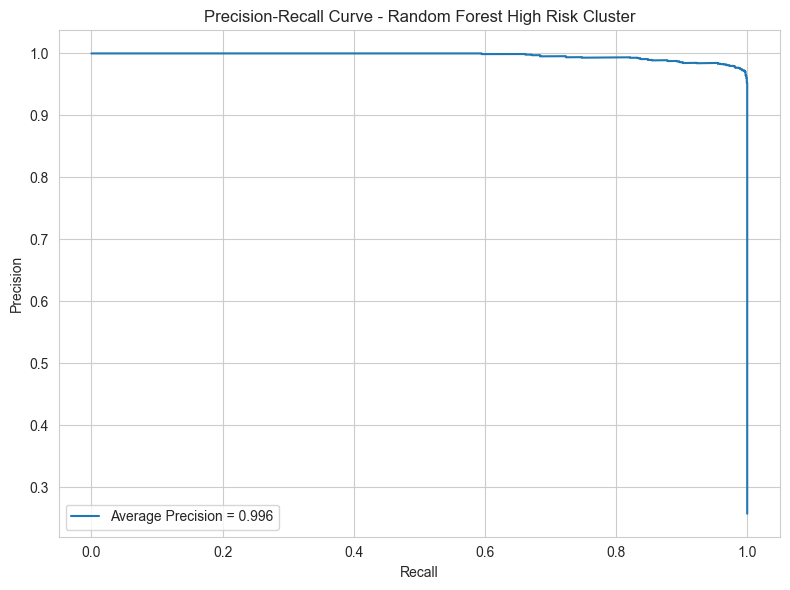

In [39]:
fpr_rf, tpr_rf, _ = roc_curve(y_true_binary_rf, y_test_probs_rf)
auc_rf = roc_auc_score(y_true_binary_rf, y_test_probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest High Risk Cluster")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/random_forest_high_risk_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

precision_rf, recall_rf, _ = precision_recall_curve(y_true_binary_rf, y_test_probs_rf)
avg_precision_rf = average_precision_score(y_true_binary_rf, y_test_probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f"Average Precision = {avg_precision_rf:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest High Risk Cluster")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/random_forest_high_risk_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 30. SHAP analysis for Random Forest

**Purpose:** Calculates Tree SHAP values for the High-Risk class using a reproducible training sample.

**Key result:** Global importance plots and value-SHAP correlations identify the strongest features and their direction of influence.



=== Random Forest Transformed Data ===
X_train_rf shape: (24000, 31)
Number of features: 31
SHAP original shape: (2000, 31, 3)
SHAP High Risk shape: (2000, 31)

=== SHAP Feature Importance - Random Forest High Risk Class ===
                       feature  importance
                    ord__PAY_3      0.0817
                    ord__PAY_2      0.0757
                    ord__PAY_0      0.0707
                    ord__PAY_4      0.0430
                    ord__PAY_6      0.0408
                    ord__PAY_5      0.0307
                 num__PAY_AMT2      0.0221
                 num__PAY_AMT1      0.0211
                 num__PAY_AMT3      0.0121
                 num__PAY_AMT4      0.0085
                num__BILL_AMT2      0.0082
                num__BILL_AMT5      0.0071
                 num__PAY_AMT5      0.0069
                num__BILL_AMT3      0.0057
                num__BILL_AMT4      0.0056
                num__BILL_AMT6      0.0052
                num__LIMIT_BAL      0.0047


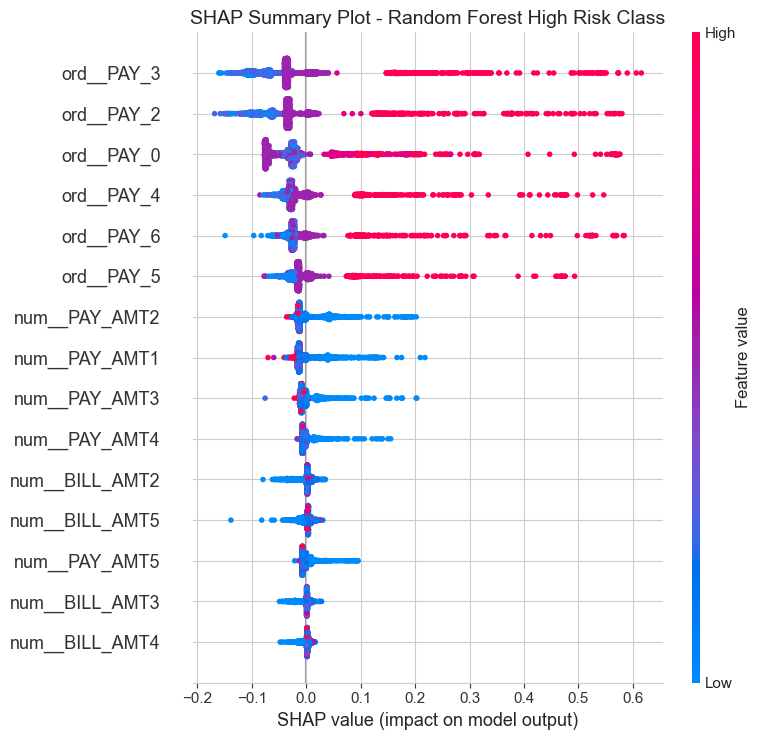

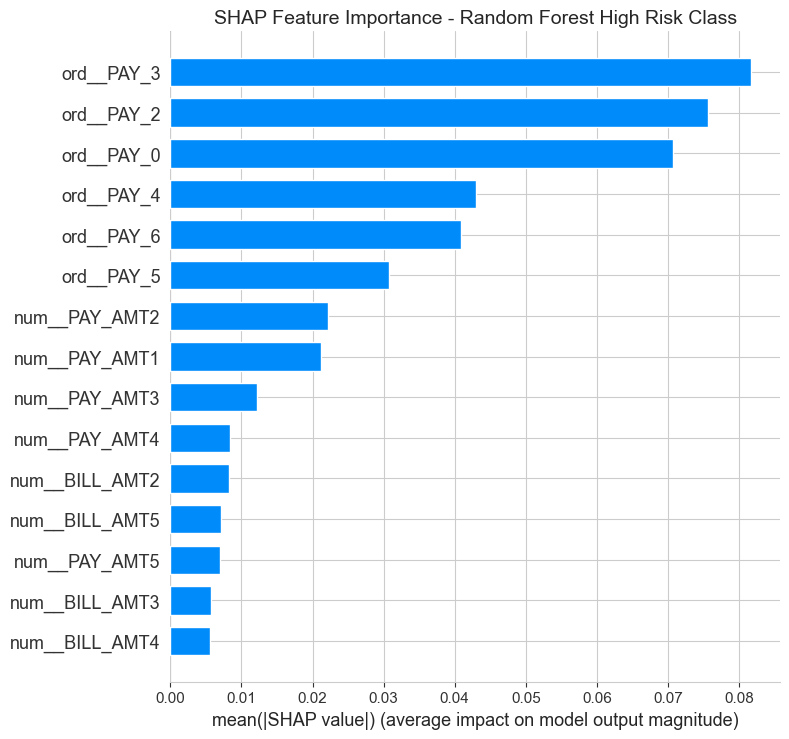


=== SHAP Direction for Top 5 Random Forest Features ===
   feature  value_shap_correlation                                            direction
ord__PAY_3                  0.8085 Higher values increase High Risk cluster probability
ord__PAY_2                  0.7999 Higher values increase High Risk cluster probability
ord__PAY_0                  0.5840 Higher values increase High Risk cluster probability
ord__PAY_4                  0.6961 Higher values increase High Risk cluster probability
ord__PAY_6                  0.6245 Higher values increase High Risk cluster probability


In [40]:
X_train_rf_transformed = model_rf.named_steps["preprocessor"].transform(x_train_rf)
X_test_rf_transformed = model_rf.named_steps["preprocessor"].transform(x_test_rf)
feature_names_rf = model_rf.named_steps["preprocessor"].get_feature_names_out()

print("\n=== Random Forest Transformed Data ===")
print(f"X_train_rf shape: {X_train_rf_transformed.shape}")
print(f"Number of features: {len(feature_names_rf)}")


rf_model_shap = RandomForestClassifier(n_estimators=best_params_rf["n_estimators"],
                                       max_depth=best_params_rf["max_depth"],
                                       min_samples_split=best_params_rf["min_samples_split"],
                                       min_samples_leaf=best_params_rf["min_samples_leaf"],
                                       random_state=RANDOM_STATE, n_jobs=-1)
rf_model_shap.fit(X_train_rf_transformed, y_train_rf)

rf_shap_size = min(2000, len(X_train_rf_transformed))
rf_shap_rng = np.random.default_rng(RANDOM_STATE)
rf_shap_indices = rf_shap_rng.choice(len(X_train_rf_transformed), size=rf_shap_size, replace=False)
X_train_rf_shap = X_train_rf_transformed[rf_shap_indices]

explainer_rf = shap.TreeExplainer(rf_model_shap)
shap_values_rf = explainer_rf.shap_values(X_train_rf_shap)

high_risk_shap_index = list(rf_model_shap.classes_).index(high_risk_cluster)

if isinstance(shap_values_rf, list):
    shap_values_high = shap_values_rf[high_risk_shap_index]
else:
    shap_values_high = shap_values_rf[:, :, high_risk_shap_index]

print("SHAP original shape:", np.shape(shap_values_rf))
print("SHAP High Risk shape:", shap_values_high.shape)

shap_importance_rf = pd.DataFrame({"feature": feature_names_rf, "importance": np.abs(shap_values_high).mean(axis=0),}).sort_values("importance", ascending=False)

print("\n=== SHAP Feature Importance - Random Forest High Risk Class ===")
print(shap_importance_rf.head(25).to_string(index=False))

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_high, X_train_rf_shap, feature_names=feature_names_rf, max_display=15, show=False,)
plt.title("SHAP Summary Plot - Random Forest High Risk Class", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/random_forest_shap_summary_high_risk.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_high, X_train_rf_shap, feature_names=feature_names_rf, plot_type="bar", max_display=15, show=False,)
plt.title("SHAP Feature Importance - Random Forest High Risk Class", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/random_forest_shap_bar_high_risk.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

rf_top5 = shap_importance_rf.head(5)["feature"].values
rf_shap_direction_rows = []

for feature in rf_top5:
    feature_index = list(feature_names_rf).index(feature)
    feature_values = X_train_rf_shap[:, feature_index]
    feature_shap_values = shap_values_high[:, feature_index]

    if np.std(feature_values) == 0 or np.std(feature_shap_values) == 0:
        correlation = np.nan
        direction = "No clear direction"
    else:
        correlation = np.corrcoef(feature_values, feature_shap_values)[0, 1]
        direction = "Higher values increase High Risk cluster probability" if correlation > 0 else "Higher values decrease High Risk cluster probability"

    rf_shap_direction_rows.append({"feature": feature, "value_shap_correlation": correlation, "direction": direction,})

rf_shap_direction = pd.DataFrame(rf_shap_direction_rows)

print("\n=== SHAP Direction for Top 5 Random Forest Features ===")
print(rf_shap_direction.to_string(index=False))


## 31. RFE with Random Forest

**Purpose:** Runs recursive feature elimination with the tuned Random Forest on transformed features.

**Key result:** The output provides a complete alternative ranking of features used to reproduce cluster labels.


In [41]:
rf_model_rfe = RandomForestClassifier(n_estimators=best_params_rf["n_estimators"],
                                      max_depth=best_params_rf["max_depth"],
                                      min_samples_split=best_params_rf["min_samples_split"],
                                      min_samples_leaf=best_params_rf["min_samples_leaf"],
                                      random_state=RANDOM_STATE, n_jobs=-1)
rfe_rf = RFE(estimator=rf_model_rfe, n_features_to_select=1, step=1,)
rfe_rf.fit(X_train_rf_transformed, y_train_rf)

rfe_ranking_rf = pd.DataFrame({"feature": feature_names_rf, "ranking": rfe_rf.ranking_,}).sort_values("ranking").reset_index(drop=True)

rfe_ranking_rf["rank"] = range(1, len(rfe_ranking_rf) + 1)

print("\n=== RFE Feature Ranking - Random Forest ===")
print(rfe_ranking_rf[["rank", "feature", "ranking"]].to_string(index=False))



=== RFE Feature Ranking - Random Forest ===
 rank                        feature  ranking
    1                     ord__PAY_3        1
    2                     ord__PAY_2        2
    3                     ord__PAY_4        3
    4                     ord__PAY_6        4
    5                     ord__PAY_0        5
    6                     ord__PAY_5        6
    7                 num__BILL_AMT5        7
    8                  num__PAY_AMT2        8
    9                 num__BILL_AMT2        9
   10                  num__PAY_AMT1       10
   11                 num__BILL_AMT3       11
   12                  num__PAY_AMT4       12
   13                 num__BILL_AMT4       13
   14                  num__PAY_AMT3       14
   15                 num__BILL_AMT1       15
   16                  num__PAY_AMT5       16
   17                 num__BILL_AMT6       17
   18                  num__PAY_AMT6       18
   19                 num__LIMIT_BAL       19
   20                       num__AG

# Part VI — Final risk segmentation outputs

This part exports the primary probability-based risk groups and retains the original cluster-based risk grouping as an additional analysis.


## 32. Logistic risk groups - PDF method

**Purpose:** Applies validation-derived probability boundaries to the non-oversampled Logistic Regression probabilities.

**Key result:** It exports customer risk groups, test-set risk performance, boundary definitions, and an observed-default-rate chart.



=== Logistic Risk Group Summary - Test ===
risk_group  customer_count  mean_predicted_probability  observed_default_rate
       Low            2920                      0.1040                 0.1171
    Medium            1895                      0.2238                 0.1842
      High            1185                      0.5079                 0.5367


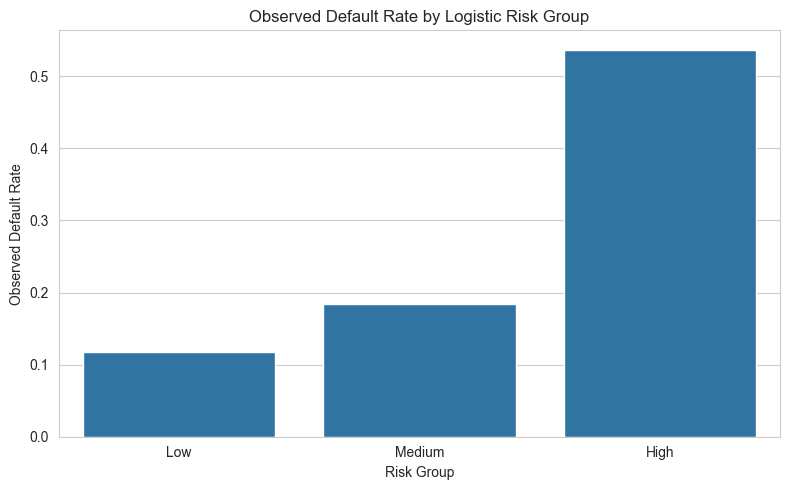

risk_groups_logistic.csv saved!
logistic_risk_summary_test.csv saved!
logistic_risk_thresholds.csv saved!


In [42]:
# Use the non-oversampled logistic model for default probabilities.
probs_log = baseline_log.predict_proba(X_full)[:, 1]

risk_groups_log = pd.cut(probs_log, bins=logistic_risk_bins, labels=logistic_risk_labels, include_lowest=True,)

# Main risk output required by the project.
df_log = pd.DataFrame({"predicted_probability": probs_log, "risk_group": risk_groups_log,})

df_log.to_csv("../outputs/risk_groups_logistic.csv", index=False)



# Report the risk groups on the untouched test set.
test_risk_groups_log = pd.cut(baseline_test_probs, bins=logistic_risk_bins, labels=logistic_risk_labels, include_lowest=True,)

logistic_test_risk = pd.DataFrame({"predicted_probability": baseline_test_probs, "risk_group": test_risk_groups_log, "observed_default": y_test.to_numpy(),})

logistic_risk_summary = (logistic_test_risk.groupby("risk_group", observed=True).agg(customer_count=("risk_group", "size"), mean_predicted_probability=("predicted_probability", "mean"), observed_default_rate=("observed_default", "mean"),).reset_index())

print("\n=== Logistic Risk Group Summary - Test ===")
print(logistic_risk_summary.to_string(index=False))

logistic_risk_summary.to_csv("../outputs/logistic_risk_summary_test.csv", index=False)

logistic_threshold_output = pd.DataFrame({"boundary": ["Low/Medium", "Medium/High"], "threshold": [low_risk_threshold, high_risk_threshold], "validation_rule": ["50th percentile of validation probability", "80th percentile of validation probability",],})
logistic_threshold_output.to_csv("../outputs/logistic_risk_thresholds.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=logistic_risk_summary, x="risk_group", y="observed_default_rate", order=logistic_risk_labels,)
plt.title("Observed Default Rate by Logistic Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Observed Default Rate")
plt.tight_layout()
plt.savefig("../figures/logistic_risk_group_default_rate.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("risk_groups_logistic.csv saved!")
print("logistic_risk_summary_test.csv saved!")
print("logistic_risk_thresholds.csv saved!")


## 33. Cluster risk groups - original method

**Purpose:** Preserves the original cluster-based approach by grouping High-Risk-cluster membership probabilities into Low, Medium, and High bands.

**Key result:** The final CSV is an additional segmentation output and the accumulated console text is written to a terminal-output file.


In [44]:
# Keep the original cluster-based risk logic as an extra analysis.
cluster_risk_bins = [0, 0.2, 0.5, 1.0]
cluster_risk_labels = ["Low", "Medium", "High"]

probs_rf = model_rf.predict_proba(X_rf)[:, high_risk_class_index]
risk_groups_rf = pd.cut(probs_rf, bins=cluster_risk_bins, labels=cluster_risk_labels, include_lowest=True,)

df_rf_out = pd.DataFrame({"probability_high_risk_cluster_membership": probs_rf, "cluster_membership_risk_group": risk_groups_rf,})

df_rf_out.to_csv("../outputs/risk_groups_rf_cluster.csv", index=False)
print("risk_groups_rf_cluster.csv saved!")
plt.close('all')


f = open("../terminal_output/terminal_output.txt", "w", encoding="utf-8")
f.write("\n".join(all_outputs))
f.close()


risk_groups_rf_cluster.csv saved!
